In [ ]:
# ============================================================================
# attention-to-bio — Delta Expression Encoder
# Clean unified notebook: run all cells top to bottom, any session
# Checkpoints used wherever available — nothing recomputed unnecessarily
# ============================================================================

# ── CELL 1: Install and imports ──────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os
import math
import sqlite3
from collections import defaultdict

import numpy as np
import pandas as pd
import scipy.sparse as sp
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Patch
from sklearn.metrics import silhouette_score

!pip install scanpy umap-learn -q
import scanpy as sc
import umap

DRIVE_PATH = '/content/drive/MyDrive/attention-to-bio'
os.makedirs(f'{DRIVE_PATH}/checkpoints', exist_ok=True)
os.makedirs(f'{DRIVE_PATH}/figures', exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

# ── Recovery utility: load from checkpoint or compute and save ──────────────
def load_or_compute(name, fn, *args, force=False, **kwargs):
    path = f'{DRIVE_PATH}/checkpoints/{name}.pt'
    if os.path.exists(path) and not force:
        print(f"  [{name}] Loading from checkpoint...")
        return torch.load(path, weights_only=False)
    print(f"  [{name}] Computing...")
    result = fn(*args, **kwargs)
    torch.save(result, path)
    print(f"  [{name}] Saved.")
    return result


Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 9.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 85.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.3/174.3 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 151.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.8/318.8 kB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 159.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
Device: cuda
GPU: NVIDIA L4


In [ ]:
# After input tensor is loaded, load matching gene set
gene_set_500_path = f'{DRIVE_PATH}/checkpoints/gene_set_500.pt'
if os.path.exists(gene_set_500_path):
    gs = torch.load(gene_set_500_path, weights_only=False)
    final_genes_500 = gs['final_genes']
    print(f"Loaded 500-gene set: {len(final_genes_500)}")

Loaded 500-gene set: 505


In [ ]:
# ── CELL 2: Load AnnData ─────────────────────────────────────────────────────
print("Loading AnnData (~2 min for 13GB)...")
adata = sc.read_h5ad(f'{DRIVE_PATH}/data/adata_v2.h5ad')
print(f"Loaded: {adata.shape}")

CELL_TYPES = sorted([ct for ct in adata.obs['naive_celltype'].unique()
                     if ct != 'Other'])
TIMEPOINTS     = ['0h', '1h', '2h', '4h', '24h', '72h']
DRUG_TIMEPOINTS = ['1h', '2h', '4h', '24h', '72h']
DRUGS          = ['Psilo', 'Ket']

psilo_animals, ket_animals = {}, {}
for tp in DRUG_TIMEPOINTS:
    psilo_animals[tp] = sorted(adata.obs[
        (adata.obs['drug'] == 'Psilo') &
        (adata.obs['time'] == tp)]['sample'].unique().tolist())
    ket_animals[tp] = sorted(adata.obs[
        (adata.obs['drug'] == 'Ket') &
        (adata.obs['time'] == tp)]['sample'].unique().tolist())
control_animals = sorted(
    adata.obs[adata.obs['drug'] == 'none']['sample'].unique().tolist())

print(f"Cell types: {len(CELL_TYPES)}")
print(f"Psilo animals/tp: { {k: len(v) for k, v in psilo_animals.items()} }")
print(f"Control animals: {len(control_animals)}")


Loading AnnData (~2 min for 13GB)...
Loaded: (322232, 26100)
Cell types: 18
Psilo animals/tp: {'1h': 3, '2h': 3, '4h': 4, '24h': 3, '72h': 4}
Control animals: 8


In [ ]:
# ── CELL 3: Pseudobulk construction ─────────────────────────────────────────
def build_pseudobulk(adata, cell_types, drug_timepoints,
                     psilo_animals, ket_animals, control_animals,
                     min_cells=10):
    pseudobulk, pop_means = {}, {}

    def mean_expr(mask):
        sub = adata[mask].X
        return np.array(sub.mean(axis=0) if sp.issparse(sub)
                        else sub.mean(axis=0)).flatten()

    print("Control baselines...")
    for animal in control_animals:
        for ct in cell_types:
            mask = ((adata.obs['sample'] == animal) &
                    (adata.obs['drug'] == 'none') &
                    (adata.obs['time'] == '0h') &
                    (adata.obs['naive_celltype'] == ct))
            if mask.sum() >= min_cells:
                pseudobulk[(animal, ct, 'none', '0h')] = mean_expr(mask)

    for drug, adict in [('Psilo', psilo_animals), ('Ket', ket_animals)]:
        print(f"{drug} pseudobulk...")
        for tp, animals in adict.items():
            for animal in animals:
                for ct in cell_types:
                    mask = ((adata.obs['sample'] == animal) &
                            (adata.obs['drug'] == drug) &
                            (adata.obs['time'] == tp) &
                            (adata.obs['naive_celltype'] == ct))
                    if mask.sum() >= min_cells:
                        pseudobulk[(animal, ct, drug, tp)] = mean_expr(mask)

    print("Population means...")
    for ct in cell_types:
        mask = ((adata.obs['drug'] == 'none') &
                (adata.obs['time'] == '0h') &
                (adata.obs['naive_celltype'] == ct))
        if mask.sum() >= min_cells:
            pop_means[('none', '0h', ct)] = mean_expr(mask)

    for drug in DRUGS:
        for tp in drug_timepoints:
            for ct in cell_types:
                mask = ((adata.obs['drug'] == drug) &
                        (adata.obs['time'] == tp) &
                        (adata.obs['naive_celltype'] == ct))
                if mask.sum() >= min_cells:
                    pop_means[(drug, tp, ct)] = mean_expr(mask)

    return {'pseudobulk': pseudobulk, 'pop_means': pop_means}

pb_data = load_or_compute('pseudobulk_v2', build_pseudobulk,
                          adata, CELL_TYPES, DRUG_TIMEPOINTS,
                          psilo_animals, ket_animals, control_animals)

# Handle both old tuple format and new dict format
if isinstance(pb_data, tuple):
    pseudobulk, pop_means = pb_data
else:
    pseudobulk = pb_data['pseudobulk']
    pop_means  = pb_data['pop_means']

print(f"Individual profiles: {len(pseudobulk)}")
print(f"Population means: {len(pop_means)}")



  [pseudobulk_v2] Loading from checkpoint...
Individual profiles: 728
Population means: 197


In [ ]:
# ── CELL 4: Gene selection ───────────────────────────────────────────────────
def select_genes(adata, pop_means, min_comparisons=5, cv_percentile=10):
    gene_names  = adata.var_names.tolist()
    gene_to_idx = {g: i for i, g in enumerate(gene_names)}

    pop_matrix = np.stack(list(pop_means.values()))
    gene_mean  = pop_matrix.mean(axis=0)
    gene_var   = pop_matrix.var(axis=0)
    cv         = gene_var / (gene_mean + 1e-6)

    conn = sqlite3.connect(
        f'{DRIVE_PATH}/data/differential_expression_v2.sqlite')
    deg_summary = pd.read_sql("""
        SELECT gene_name,
               MAX(ABS(log2FoldChange)) as max_lfc,
               MIN(padj)               as min_padj,
               COUNT(*)                as n_comparisons
        FROM de_results WHERE padj < 0.05
        GROUP BY gene_name ORDER BY max_lfc DESC
    """, conn)
    conn.close()

    robust = set(deg_summary[deg_summary['n_comparisons'] >= min_comparisons
                             ]['gene_name'].tolist())
    sel_idx = [gene_to_idx[g] for g in robust if g in gene_to_idx]
    cv_thresh = np.percentile(cv[sel_idx], cv_percentile)

    final_genes = [g for g in robust
                   if g in gene_to_idx and cv[gene_to_idx[g]] >= cv_thresh]

    # Score and keep top 500
    deg_summary['cv'] = deg_summary['gene_name'].map(
        lambda g: cv[gene_to_idx[g]] if g in gene_to_idx else 0)
    deg_summary['score'] = deg_summary['n_comparisons'] * deg_summary['cv']
    top500 = deg_summary.sort_values('score', ascending=False).head(500)
    final_genes = top500['gene_name'].tolist()

    # force = ['Grin2a','Grin2b','Shisa7','Shisa9','Htr2a',
             # 'Bdnf','Arc','Fos','Camk1d','Maoa','Maob',
             # 'Htr1a','Htr2c','Tph2','Slc6a4','Comt']
    force = ['Grin2a', 'Grin2b', 'Shisa7', 'Shisa9', 'Camk1d',
         'Arc', 'Fos', 'Bdnf', 'Htr2a', 'Htr1a', 'Htr2c',
         'Tph2', 'Slc6a4', 'Comt', 'Maoa', 'Maob',
         'Sv2b', 'Nos1ap', 'Grm3', 'Gria1', 'Cacna1e']
    for g in force:
        if g in gene_to_idx and g not in final_genes:
            final_genes.append(g)

    final_idx = [gene_to_idx[g] for g in final_genes]
    return {'final_genes': final_genes, 'final_gene_indices': final_idx,
            'gene_names': gene_names, 'gene_to_idx': gene_to_idx}

# gene_data  = load_or_compute('gene_set_v2', select_genes, adata, pop_means)
# Change force=False to force=True to regenerate
gene_data = load_or_compute('gene_set_500_v2', select_genes,
                            adata, pop_means, force=True)

final_genes_500     = gene_data['final_genes']
final_gene_indices_500 = gene_data['final_gene_indices']
gene_to_idx         = gene_data['gene_to_idx']
print(f"Gene set: {len(final_genes_500)} genes")

key_check = ['Grin2a','Grin2b','Shisa7','Shisa9','Htr2a','Bdnf','Arc','Fos']
for g in key_check:
    print(f"  {g}: {'YES' if g in final_genes_500 else 'NO'}")


  [gene_set_500_v2] Computing...
  [gene_set_500_v2] Saved.
Gene set: 510 genes
  Grin2a: YES
  Grin2b: YES
  Shisa7: YES
  Shisa9: YES
  Htr2a: YES
  Bdnf: YES
  Arc: YES
  Fos: YES


In [ ]:
# ── CELL 5: Build input tensors (V5 — sentinel for unmeasured timepoints) ───
NOT_MEASURED = -1.0

def build_input_tensors_v5(pseudobulk, pop_means, final_gene_indices,
                           cell_types, drug_timepoints, drugs,
                           psilo_animals, ket_animals, control_animals):
    animals_by_drug  = {'Psilo': psilo_animals, 'Ket': ket_animals}
    celltype_to_idx  = {ct: i for i, ct in enumerate(sorted(cell_types))}
    drug_to_idx      = {'Psilo': 0, 'Ket': 1}
    ALL_TP           = ['0h', '1h', '2h', '4h', '24h', '72h']
    matrices, metadata = [], []

    # Individual animal examples
    for drug in drugs:
        for tp, animals in animals_by_drug[drug].items():
            for animal in animals:
                for ct in cell_types:
                    akey = (animal, ct, drug, tp)
                    bkey = ('none', '0h', ct)
                    if akey not in pseudobulk or bkey not in pop_means:
                        continue
                    vecs = []
                    for t in ALL_TP:
                        if t == '0h':
                            vecs.append(pop_means[bkey][final_gene_indices])
                        elif t == tp:
                            vecs.append(pseudobulk[akey][final_gene_indices])
                        else:
                            vecs.append(np.full(len(final_gene_indices),
                                                NOT_MEASURED, dtype=np.float32))
                    matrices.append(np.stack(vecs, axis=1))
                    metadata.append({
                        'animal': animal, 'cell_type': ct,
                        'drug': drug, 'timepoint': tp,
                        'timepoint_idx': ALL_TP.index(tp),
                        'celltype_idx': celltype_to_idx[ct],
                        'drug_idx': drug_to_idx[drug],
                        'example_type': 'individual'})

    # Population mean examples — full timelines for temporal grammar
    for drug in drugs:
        for ct in cell_types:
            bkey = ('none', '0h', ct)
            if bkey not in pop_means:
                continue
            if not all((drug, tp, ct) in pop_means for tp in drug_timepoints):
                continue
            vecs = []
            for t in ALL_TP:
                if t == '0h':
                    vecs.append(pop_means[bkey][final_gene_indices])
                else:
                    vecs.append(pop_means[(drug, t, ct)][final_gene_indices])
            matrices.append(np.stack(vecs, axis=1))
            metadata.append({
                'animal': 'population', 'cell_type': ct,
                'drug': drug, 'timepoint': 'all',
                'timepoint_idx': -1,
                'celltype_idx': celltype_to_idx[ct],
                'drug_idx': drug_to_idx[drug],
                'example_type': 'population'})

    return {
        'input_tensor': torch.tensor(np.stack(matrices), dtype=torch.float32),
        'metadata': metadata,
        'celltype_to_idx': celltype_to_idx,
        'drug_to_idx': drug_to_idx,
    }

#td = load_or_compute('input_tensors_v5', build_input_tensors_v5,
 #                    pseudobulk, pop_means, final_gene_indices_500,
  #                   CELL_TYPES, DRUG_TIMEPOINTS, DRUGS,
   #                  psilo_animals, ket_animals, control_animals)

td = load_or_compute('input_tensors_v5_v2', build_input_tensors_v5,
                     pseudobulk, pop_means, final_gene_indices_500,
                     CELL_TYPES, DRUG_TIMEPOINTS, DRUGS,
                     psilo_animals, ket_animals, control_animals,
                     force=True)

input_tensor_v5 = td['input_tensor']
metadata_v5     = td['metadata']
celltype_to_idx = td['celltype_to_idx']
drug_to_idx     = td['drug_to_idx']

N_GENES      = len(final_genes_500)
N_TIMEPOINTS = 6
N_CELL_TYPES = len(celltype_to_idx)
N_DRUGS      = len(drug_to_idx)

n_ind = sum(1 for m in metadata_v5 if m['example_type'] == 'individual')
n_pop = sum(1 for m in metadata_v5 if m['example_type'] == 'population')
print(f"Input tensor: {input_tensor_v5.shape}")
print(f"Individual: {n_ind} | Population: {n_pop}")


  [input_tensors_v5_v2] Computing...
  [input_tensors_v5_v2] Saved.
Input tensor: torch.Size([623, 510, 6])
Individual: 588 | Population: 35


In [ ]:
# ── CELL 6: DEG labels ───────────────────────────────────────────────────────
DOWN, NEUTRAL, UP, BASELINE = 0, 1, 2, 3
class_names = {0: 'DOWN', 1: 'NEUTRAL', 2: 'UP', 3: 'BASELINE'}
LFC_THRESH, PADJ_THRESH = 0.3, 0.05

def build_labels(metadata_v5, final_genes_500, gene_to_idx, N_GENES,
                 N_TIMEPOINTS):
    conn = sqlite3.connect(
        f'{DRIVE_PATH}/data/differential_expression_v2.sqlite')
    deg_df = pd.read_sql(
        "SELECT gene_name, celltype, treatment_time, treatment_drug, "
        "log2FoldChange, padj FROM de_results", conn)
    conn.close()

    deg_lookup = {}
    for _, row in deg_df.iterrows():
        lfc, padj = row['log2FoldChange'], row['padj']
        if padj < PADJ_THRESH:
            label = UP if lfc >= LFC_THRESH else (
                DOWN if lfc <= -LFC_THRESH else NEUTRAL)
        else:
            label = NEUTRAL
        deg_lookup[(row['gene_name'], row['celltype'],
                    row['treatment_drug'], row['treatment_time'])] = label

    TPLIST = ['0h', '1h', '2h', '4h', '24h', '72h']
    labels = torch.full((len(metadata_v5), N_GENES, N_TIMEPOINTS),
                        NEUTRAL, dtype=torch.long)
    for ex_idx, meta in enumerate(metadata_v5):
        ct, drug = meta['cell_type'], meta['drug']
        for ti, tp in enumerate(TPLIST):
            if tp == '0h':
                labels[ex_idx, :, ti] = BASELINE
                continue
            for gi, gene in enumerate(final_genes_500):
                key = (gene, ct, drug, tp)
                if key in deg_lookup:
                    labels[ex_idx, gi, ti] = deg_lookup[key]
    return labels

#label_tensor_v5 = load_or_compute('label_tensor_v5', build_labels,
 #                                 metadata_v5, final_genes_500, gene_to_idx,
  #                                N_GENES, N_TIMEPOINTS)

label_tensor_v5 = load_or_compute('label_tensor_v5_v2', build_labels,
                                  metadata_v5, final_genes_500, gene_to_idx,
                                  N_GENES, N_TIMEPOINTS,
                                  force=True)

flat = label_tensor_v5.flatten()
print("Label distribution:")
for cls, name in [(DOWN,'DOWN'),(NEUTRAL,'NEUTRAL'),
                  (UP,'UP'),(BASELINE,'BASELINE')]:
    n = (flat == cls).sum().item()
    print(f"  {name}: {n:,} ({n/len(flat)*100:.1f}%)")


  [label_tensor_v5_v2] Computing...
  [label_tensor_v5_v2] Saved.
Label distribution:
  DOWN: 30,492 (1.6%)
  NEUTRAL: 1,493,808 (78.4%)
  UP: 64,350 (3.4%)
  BASELINE: 317,730 (16.7%)


In [ ]:
# ── CELL 7: Model definition ─────────────────────────────────────────────────
# ── CELL 7: Model definition ─────────────────────────────────────────────────
import math

class DeltaExpressionEncoder(nn.Module):
    def __init__(self, n_genes, n_timepoints, n_cell_types, n_drugs,
                 n_classes=4, d_model=128, n_heads=4, n_layers=4,
                 d_ff=512, dropout=0.05):
        super().__init__()
        self.n_genes, self.n_timepoints, self.d_model = (
            n_genes, n_timepoints, d_model)
        self.input_proj        = nn.Linear(1, d_model)
        self.gene_embedding    = nn.Embedding(n_genes, d_model)
        self.register_buffer('time_encoding',
                             self._sinusoidal(n_timepoints, d_model))
        self.celltype_embedding = nn.Embedding(n_cell_types, d_model)
        self.drug_embedding    = nn.Embedding(n_drugs, d_model)
        self.mask_token        = nn.Parameter(torch.randn(d_model))
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff,
            dropout=dropout, batch_first=True, norm_first=True)
        self.transformer       = nn.TransformerEncoder(enc_layer,
                                                       num_layers=n_layers)
        self.classification_head = nn.Linear(d_model, n_classes)
        self.input_norm        = nn.LayerNorm(d_model)
        self.dropout_layer     = nn.Dropout(dropout)

    def _sinusoidal(self, n, d):
        pe  = torch.zeros(n, d)
        pos = torch.arange(0, n).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d, 2).float() *
                        -(math.log(10000.0) / d))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        return pe

    def normalize(self, x):
        flat = x.reshape(x.shape[0], -1)
        mu   = flat.mean(1, keepdim=True)
        std  = flat.std(1, keepdim=True) + 1e-6
        return ((flat - mu) / std).reshape(x.shape)

    def forward(self, x, ct_ids, drug_ids, mask=None):
        B = x.shape[0]
        tokens = self.input_proj(self.normalize(x).reshape(B, -1).unsqueeze(-1))
        g_ids = torch.arange(self.n_genes, device=x.device)
        g_ids = g_ids.unsqueeze(1).expand(-1, self.n_timepoints).reshape(-1)
        t_ids = torch.arange(self.n_timepoints, device=x.device)
        t_ids = t_ids.unsqueeze(0).expand(self.n_genes, -1).reshape(-1)
        tokens = (tokens
                  + self.gene_embedding(g_ids)
                  + self.time_encoding[t_ids]
                  + (self.celltype_embedding(ct_ids) +
                     self.drug_embedding(drug_ids)).unsqueeze(1))
        tokens = self.dropout_layer(self.input_norm(tokens))
        if mask is not None:
            mf = mask.reshape(B, -1)
            mt = self.mask_token.unsqueeze(0).unsqueeze(0).expand(
                B, tokens.shape[1], -1)
            tokens = torch.where(mf.unsqueeze(-1), mt, tokens)
        out    = self.transformer(tokens)
        logits = self.classification_head(out)
        return out, logits

    def get_embedding(self, x, ct_ids, drug_ids):
        out, _ = self.forward(x, ct_ids, drug_ids)
        return out.mean(dim=1)

    def get_attention_weights(self, x, ct_ids, drug_ids):
      """Extract attention weights from all layers"""
      B = x.shape[0]
      tokens = self.input_proj(self.normalize(x).reshape(B, -1).unsqueeze(-1))

      g_ids = torch.arange(self.n_genes, device=x.device)
      g_ids = g_ids.unsqueeze(1).expand(-1, self.n_timepoints).reshape(-1)
      t_ids = torch.arange(self.n_timepoints, device=x.device)
      t_ids = t_ids.unsqueeze(0).expand(self.n_genes, -1).reshape(-1)

      tokens = (tokens
                + self.gene_embedding(g_ids)
                + self.time_encoding[t_ids]
                + (self.celltype_embedding(ct_ids) +
                  self.drug_embedding(drug_ids)).unsqueeze(1))
      tokens = self.dropout_layer(self.input_norm(tokens))

      # Extract attention weights layer by layer
      all_attn_weights = []
      x_curr = tokens
      for layer in self.transformer.layers:
          # Use the self-attention module directly with need_weights=True
          attn_out, attn_weights = layer.self_attn(
              x_curr, x_curr, x_curr,
              need_weights=True,
              average_attn_weights=True  # average across heads
          )
          all_attn_weights.append(attn_weights.detach().cpu())
          # Run the rest of the layer normally
          x_curr = layer(x_curr)

      return all_attn_weights  # list of (B, seq_len, seq_len) tensors

# ── Now set dimensions and instantiate ───────────────────────────────────────
N_GENES      = input_tensor_v5.shape[1]
N_TIMEPOINTS = input_tensor_v5.shape[2]
N_CELL_TYPES = len(celltype_to_idx)
N_DRUGS      = len(drug_to_idx)

print(f"N_GENES confirmed from tensor: {N_GENES}")

model = DeltaExpressionEncoder(
    n_genes=N_GENES, n_timepoints=N_TIMEPOINTS,
    n_cell_types=N_CELL_TYPES, n_drugs=N_DRUGS).to(device)

print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

# Override N_GENES from input tensor — authoritative source
N_GENES = input_tensor_v5.shape[1]
print(f"N_GENES confirmed from tensor: {N_GENES}")
#N_GENES      = input_tensor_v5.shape[1]  # 505, not 2079
N_TIMEPOINTS = input_tensor_v5.shape[2]  # 6
N_CELL_TYPES = len(celltype_to_idx)
N_DRUGS      = len(drug_to_idx)

# Also sync final_genes_500 with input tensor
# The 500-gene subset was built separately from gene_set_v2
gene_set_500 = torch.load(
    f'{DRIVE_PATH}/checkpoints/gene_set_v2.pt',
    weights_only=False)

# Check if input_tensors_v5 has its own gene list saved
td_check = torch.load(
    f'{DRIVE_PATH}/checkpoints/input_tensors_v5.pt',
    weights_only=False)
if 'final_genes' in td_check:
    final_genes_500 = td_check['final_genes']
    print(f"Gene list from input tensor checkpoint: {len(final_genes_500)}")
else:
    print(f"Using N_GENES from tensor shape: {N_GENES}")

print(f"N_GENES: {N_GENES}")
print(f"N_TIMEPOINTS: {N_TIMEPOINTS}")

# Now instantiate model with correct dimensions
model = DeltaExpressionEncoder(
    n_genes=N_GENES, n_timepoints=N_TIMEPOINTS,
    n_cell_types=N_CELL_TYPES, n_drugs=N_DRUGS).to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

N_GENES confirmed from tensor: 510


/tmp/ipykernel_1665/2717052188.py:22: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer       = nn.TransformerEncoder(enc_layer,


Parameters: 862,084
N_GENES confirmed from tensor: 510
Using N_GENES from tensor shape: 510
N_GENES: 510
N_TIMEPOINTS: 6
Parameters: 862,084


Loaded final checkpoint | loss=0.7655 | acc=0.694
Training done. Epochs: 300 | loss=0.7655 | acc=0.694


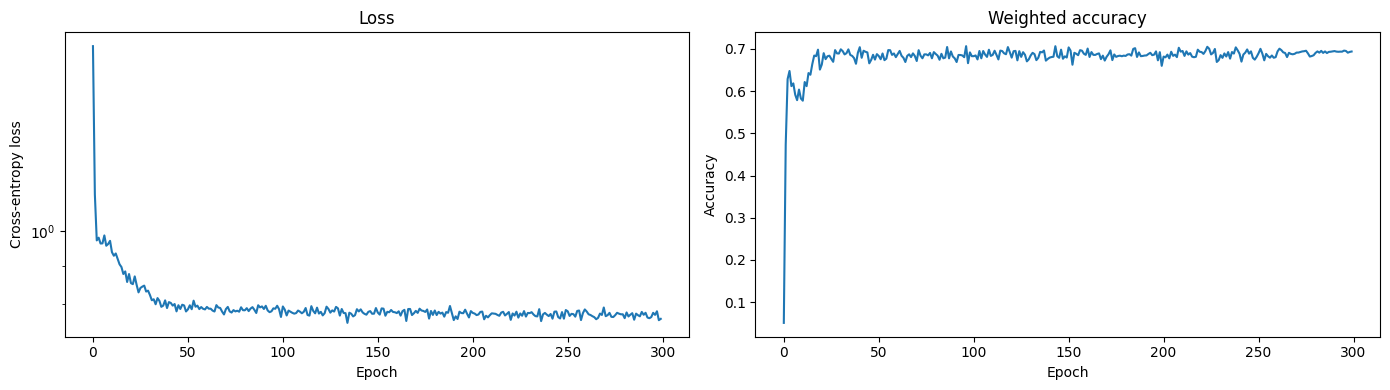

In [ ]:
# ── CELL 8: Training (resumes from checkpoint automatically) ─────────────────

class DeltaDataset(Dataset):
    def __init__(self, X, Y, meta):
        self.X, self.Y, self.meta = X, Y, meta
    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        return {'expression': self.X[i], 'labels': self.Y[i],
                'celltype_idx': torch.tensor(self.meta[i]['celltype_idx']),
                'drug_idx':     torch.tensor(self.meta[i]['drug_idx']),
                'timepoint_idx':torch.tensor(self.meta[i]['timepoint_idx']),
                'example_type': self.meta[i]['example_type']}

def get_warmup_scheduler(opt, warmup, total):
    def lr_lambda(ep):
        if ep < warmup:
            return ep / warmup
        p = (ep - warmup) / (total - warmup)
        return 0.5 * (1 + math.cos(math.pi * p))
    return torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda)

flat_v5 = label_tensor_v5.flatten()
lc      = torch.tensor([(flat_v5==c).sum().float()
                         for c in [DOWN, NEUTRAL, UP, BASELINE]])
cw      = (1.0/lc) / (1.0/lc).sum() * 4
criterion = nn.CrossEntropyLoss(weight=cw.to(device))
dataset   = DeltaDataset(input_tensor_v5, label_tensor_v5, metadata_v5)
loader    = DataLoader(dataset, batch_size=16, shuffle=True)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)
scheduler = get_warmup_scheduler(optimizer, warmup=20, total=300)

# ── Auto-resume: check final checkpoint first, then epoch checkpoints ─────
start_epoch, losses, accuracies = 0, [], []

final_path = f'{DRIVE_PATH}/checkpoints/delta_v5_v2_final.pt'
if os.path.exists(final_path):
    ckpt = torch.load(final_path, weights_only=False)
    model.load_state_dict(ckpt['model_state'])
    losses     = ckpt['losses']
    accuracies = ckpt.get('accuracies', [])
    start_epoch = 300
    print(f"Loaded final checkpoint | "
          f"loss={losses[-1]:.4f} | acc={accuracies[-1]:.3f}")
else:
    for ep in range(275, -1, -25):
        ckpt_path = f'{DRIVE_PATH}/checkpoints/delta_v5_v2_epoch{ep}.pt'
        if os.path.exists(ckpt_path):
            ckpt = torch.load(ckpt_path, weights_only=False)
            model.load_state_dict(ckpt['model_state'])
            optimizer.load_state_dict(ckpt['optimizer_state'])
            if 'scheduler_state' in ckpt:
                scheduler.load_state_dict(ckpt['scheduler_state'])
            losses     = ckpt['losses']
            accuracies = ckpt.get('accuracies', [])
            start_epoch = ckpt['epoch'] + 1
            print(f"Resumed from epoch {ckpt['epoch']} | "
                  f"loss={losses[-1]:.4f} | acc={accuracies[-1]:.3f}")
            break

    if start_epoch == 0:
        print("No checkpoint — training from scratch")

TRAIN = start_epoch < 300

if TRAIN:
    for epoch in range(start_epoch, 300):
        model.train()
        ep_loss, ep_correct, ep_total, n_b = 0, 0, 0, 0

        for batch in loader:
            expr     = batch['expression'].to(device)
            labels   = batch['labels'].to(device)
            ct_ids   = batch['celltype_idx'].to(device)
            drug_ids = batch['drug_idx'].to(device)
            tp_idx   = batch['timepoint_idx'].to(device)
            ex_types = batch['example_type']

            is_real     = (expr != NOT_MEASURED)
            mask        = (torch.rand_like(expr) < 0.25) & is_real
            out, logits = model(expr, ct_ids, drug_ids, mask=mask)

            loss_mask = torch.zeros_like(expr, dtype=torch.bool)
            for i, et in enumerate(ex_types):
                t = tp_idx[i].item()
                if et == 'individual' and t >= 0:
                    loss_mask[i, :, t] = mask[i, :, t]
                else:
                    loss_mask[i, :, 1:] = mask[i, :, 1:]

            lmf = loss_mask.reshape(expr.shape[0], -1)
            ml  = logits.reshape(-1, 4)[lmf.reshape(-1)]
            tl  = labels.reshape(-1)[lmf.reshape(-1)]
            if tl.shape[0] == 0:
                continue

            loss = criterion(ml, tl)
            ep_correct += (ml.argmax(1) == tl).sum().item()
            ep_total   += tl.shape[0]

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            ep_loss += loss.item(); n_b += 1

        scheduler.step()
        avg_loss = ep_loss / n_b
        avg_acc  = ep_correct / ep_total
        losses.append(avg_loss)
        accuracies.append(avg_acc)

        if epoch % 25 == 0:
            print(f"Epoch {epoch:3d} | Loss: {avg_loss:.4f} | "
                  f"Acc: {avg_acc:.3f} | LR: {scheduler.get_last_lr()[0]:.6f}")
            torch.save({
                'epoch': epoch,
                'model_state': model.state_dict(),
                'optimizer_state': optimizer.state_dict(),
                'scheduler_state': scheduler.state_dict(),
                'losses': losses, 'accuracies': accuracies,
            }, f'{DRIVE_PATH}/checkpoints/delta_v5_v2_epoch{epoch}.pt')

    torch.save({
        'epoch': 300,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'scheduler_state': scheduler.state_dict(),
        'losses': losses, 'accuracies': accuracies,
        'final_genes': final_genes_500,
        'celltype_to_idx': celltype_to_idx,
        'drug_to_idx': drug_to_idx,
    }, f'{DRIVE_PATH}/checkpoints/delta_v5_v2_final.pt')
    print("Training complete.")
else:
    print(f"Training done. Epochs: {len(losses)} | "
          f"loss={losses[-1]:.4f} | acc={accuracies[-1]:.3f}")

# ── Loss curve ────────────────────────────────────────────────────────────
if losses:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    ax1.plot(losses)
    ax1.set_title('Loss')
    ax1.set_yscale('log')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Cross-entropy loss')
    ax2.plot(accuracies)
    ax2.set_title('Weighted accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    plt.tight_layout()
    plt.savefig(f'{DRIVE_PATH}/figures/training_curves.png', dpi=150)
    plt.show()

In [ ]:
# ── CELL 9: Load best checkpoint (epoch 50 — best embedding structure) ───────
BEST_EPOCH = 150
# best_ckpt_path = f'{DRIVE_PATH}/checkpoints/delta_v5_epoch{BEST_EPOCH}.pt'
best_ckpt_path = f'{DRIVE_PATH}/checkpoints/delta_v5_v2_epoch{BEST_EPOCH}.pt'

if os.path.exists(best_ckpt_path):
    ckpt = torch.load(best_ckpt_path, weights_only=False)
    model.load_state_dict(ckpt['model_state'])
    print(f"Loaded epoch {BEST_EPOCH} checkpoint for evaluation")
    print(f"Loss: {ckpt['losses'][-1]:.4f} | "
          f"Acc: {ckpt['accuracies'][-1]:.3f}")
else:
    print(f"Epoch {BEST_EPOCH} checkpoint not found — using current weights")

model.eval()
input_clean = input_tensor_v5.clone()
input_clean[input_clean == NOT_MEASURED] = 0.0


Loaded epoch 150 checkpoint for evaluation
Loss: 0.7804 | Acc: 0.703


Loading cached embeddings...
Embeddings: (623, 128)
Drug silhouette:      0.0618
Cell type silhouette: -0.0437


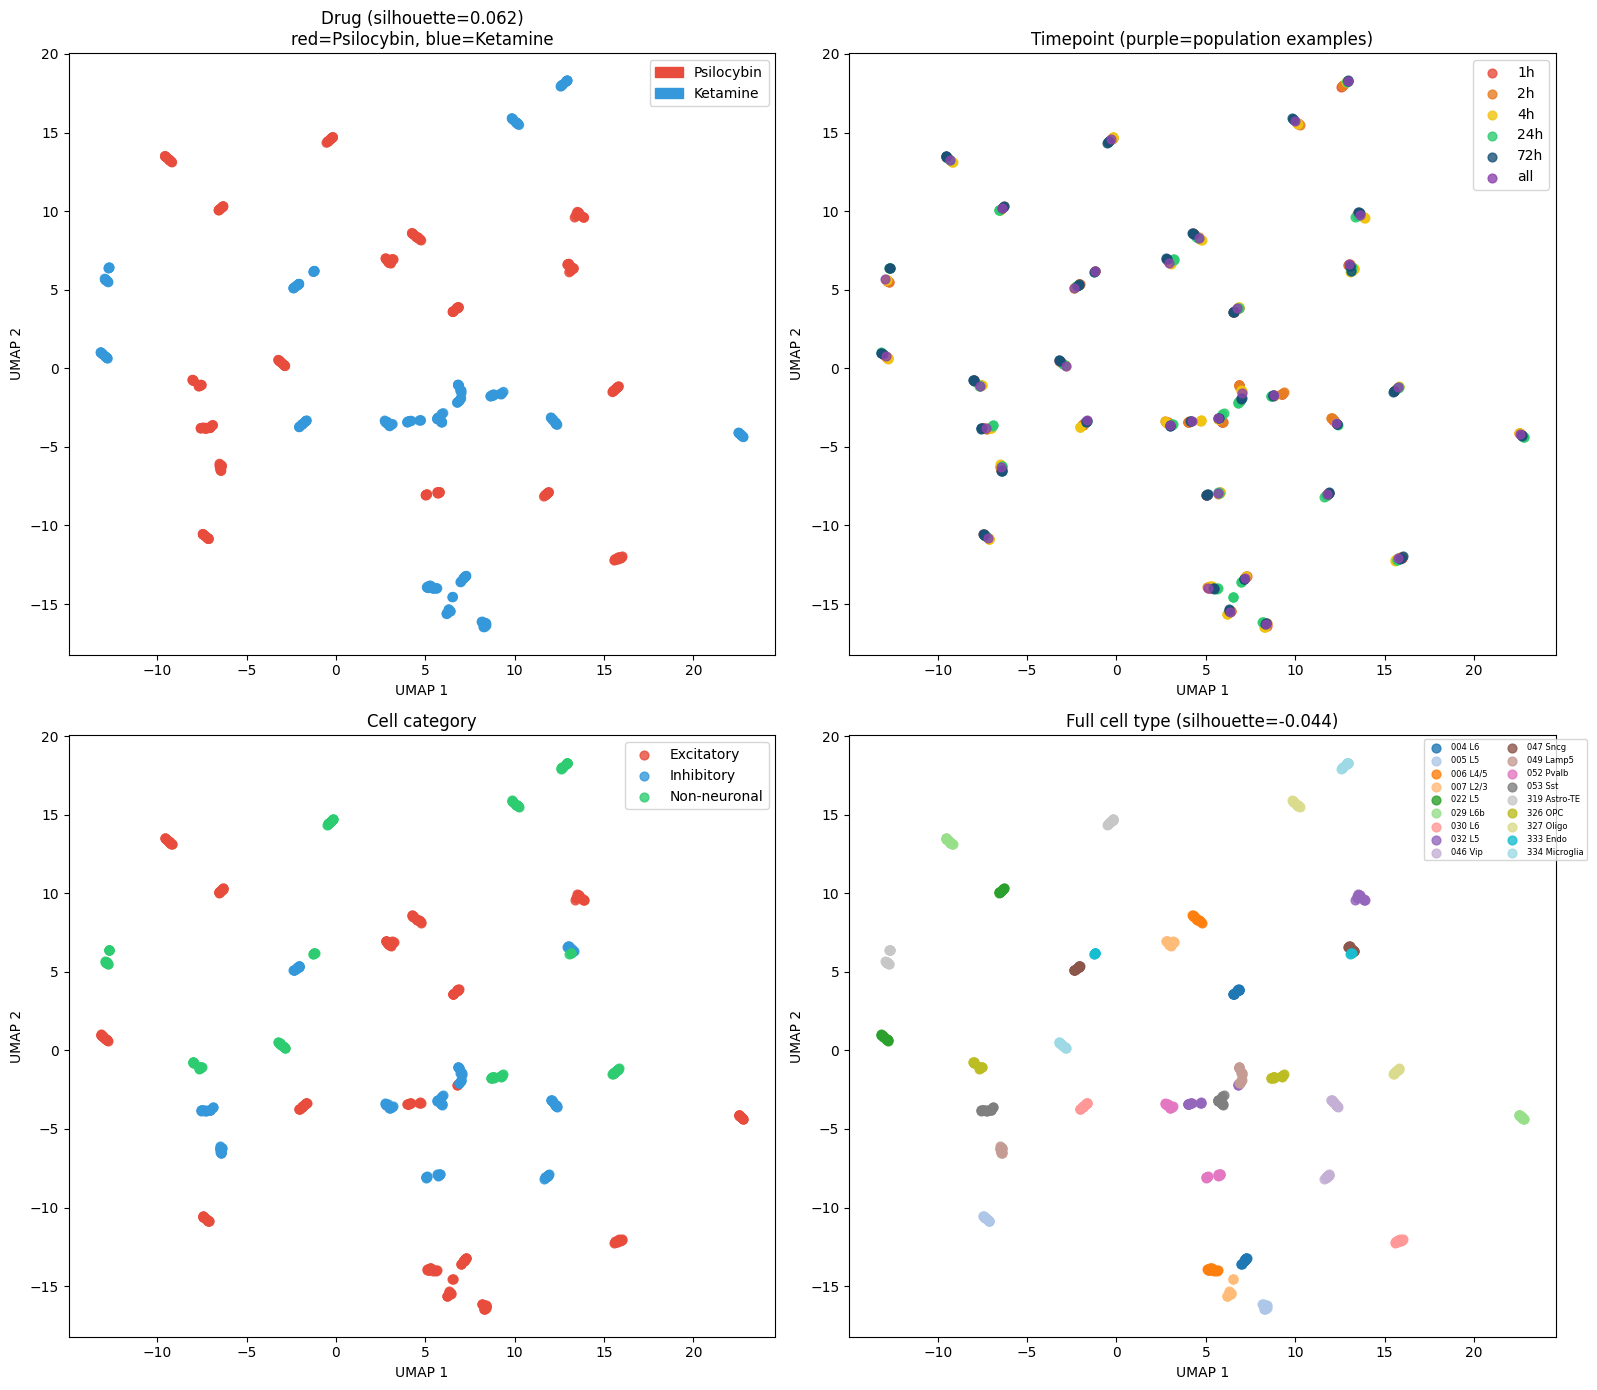

In [ ]:
# ── CELL 10: Extract embeddings + UMAP ──────────────────────────────────────
emb_cache = f'{DRIVE_PATH}/checkpoints/embeddings_v5_v2_e{BEST_EPOCH}.npy'
e2d_cache = f'{DRIVE_PATH}/checkpoints/embeddings_2d_v5_v2_e{BEST_EPOCH}.npy'

if os.path.exists(emb_cache) and os.path.exists(e2d_cache):
    print("Loading cached embeddings...")
    embeddings = np.load(emb_cache)
    emb_2d     = np.load(e2d_cache)
else:
    print("Extracting embeddings...")
    all_emb = []
    with torch.no_grad():
        for i in range(0, len(input_tensor_v5), 32):
            j   = min(i+32, len(input_tensor_v5))
            be  = input_clean[i:j].to(device)
            bc  = torch.tensor([metadata_v5[k]['celltype_idx']
                                 for k in range(i,j)]).to(device)
            bd  = torch.tensor([metadata_v5[k]['drug_idx']
                                 for k in range(i,j)]).to(device)
            all_emb.append(model.get_embedding(be, bc, bd).cpu())
    embeddings = torch.cat(all_emb).numpy()
    reducer    = umap.UMAP(n_components=2, random_state=42,
                           n_neighbors=15, min_dist=0.1)
    emb_2d     = reducer.fit_transform(embeddings)
    np.save(emb_cache, embeddings)
    np.save(e2d_cache, emb_2d)

print(f"Embeddings: {embeddings.shape}")

# Silhouette scores
drug_labels = [0 if m['drug'] == 'Psilo' else 1 for m in metadata_v5]
ct_labels   = [m['celltype_idx'] for m in metadata_v5]
sil_drug    = silhouette_score(emb_2d, drug_labels)
sil_ct      = silhouette_score(emb_2d, ct_labels)
print(f"Drug silhouette:      {sil_drug:.4f}")
print(f"Cell type silhouette: {sil_ct:.4f}")

# 4-panel UMAP
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Drug
dc = ['#E74C3C' if m['drug']=='Psilo' else '#3498DB' for m in metadata_v5]
axes[0,0].scatter(emb_2d[:,0], emb_2d[:,1], c=dc, s=40, alpha=0.8)
axes[0,0].set_title(f'Drug (silhouette={sil_drug:.3f})\n'
                    'red=Psilocybin, blue=Ketamine')
axes[0,0].legend(handles=[Patch(color='#E74C3C', label='Psilocybin'),
                           Patch(color='#3498DB', label='Ketamine')])

# Timepoint
tp_colors = {'1h':'#E74C3C','2h':'#E67E22','4h':'#F1C40F',
             '24h':'#2ECC71','72h':'#1A5276','all':'#8E44AD'}
for tp, col in tp_colors.items():
    idx = [i for i,m in enumerate(metadata_v5) if m['timepoint']==tp]
    if idx:
        axes[0,1].scatter(emb_2d[idx,0], emb_2d[idx,1],
                          c=col, s=40, alpha=0.8, label=tp)
axes[0,1].set_title('Timepoint (purple=population examples)')
axes[0,1].legend()

# Cell category
def cell_cat(ct):
    if 'Glut' in ct: return 'Excitatory'
    if 'Gaba' in ct: return 'Inhibitory'
    return 'Non-neuronal'
cat_col = {'Excitatory':'#E74C3C','Inhibitory':'#3498DB',
           'Non-neuronal':'#2ECC71'}
for cat, col in cat_col.items():
    idx = [i for i,m in enumerate(metadata_v5) if cell_cat(m['cell_type'])==cat]
    axes[1,0].scatter(emb_2d[idx,0], emb_2d[idx,1],
                      c=col, s=40, alpha=0.8, label=cat)
axes[1,0].set_title('Cell category')
axes[1,0].legend()

# Full cell type
cts_uniq   = sorted(set(m['cell_type'] for m in metadata_v5))
ct_cmap    = dict(zip(cts_uniq, cm.tab20(np.linspace(0,1,len(cts_uniq)))))
for ct in cts_uniq:
    idx   = [i for i,m in enumerate(metadata_v5) if m['cell_type']==ct]
    short = ' '.join(ct.split()[:2])
    axes[1,1].scatter(emb_2d[idx,0], emb_2d[idx,1],
                      c=[ct_cmap[ct]], s=40, alpha=0.8, label=short)
axes[1,1].set_title(f'Full cell type (silhouette={sil_ct:.3f})')
axes[1,1].legend(fontsize=6, ncol=2, bbox_to_anchor=(1.05,1))

for ax in axes.flat:
    ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/figures/umap_v5_e{BEST_EPOCH}.png',
            dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── CELL 11: Per-class and per-cell-type accuracy ────────────────────────────
class_correct   = defaultdict(int)
class_total     = defaultdict(int)
celltype_correct = defaultdict(int)
celltype_total   = defaultdict(int)

with torch.no_grad():
    for i in range(0, len(input_tensor_v5), 32):
        j       = min(i+32, len(input_tensor_v5))
        be      = input_clean[i:j].to(device)
        bc      = torch.tensor([metadata_v5[k]['celltype_idx']
                                 for k in range(i,j)]).to(device)
        bd      = torch.tensor([metadata_v5[k]['drug_idx']
                                 for k in range(i,j)]).to(device)
        _, lgs  = model(be, bc, bd)
        pred    = lgs.argmax(-1).cpu().reshape(j-i, N_GENES, N_TIMEPOINTS)
        true    = label_tensor_v5[i:j]

        for b in range(j-i):
            meta   = metadata_v5[i+b]
            ct     = meta['cell_type']
            tp_i   = meta['timepoint_idx']
            et     = meta['example_type']
            cols   = [tp_i] if (et=='individual' and tp_i>=0) else list(range(1,6))
            for t in cols:
                for gi in range(N_GENES):
                    tl = true[b, gi, t].item()
                    pl = pred[b, gi, t].item()
                    class_total[tl]   += 1
                    celltype_total[ct] += 1
                    if pl == tl:
                        class_correct[tl]   += 1
                        celltype_correct[ct] += 1

print("Per-class accuracy:")
print(f"{'Class':<12} {'Correct':>8} {'Total':>8} {'Acc':>8}")
print("-" * 42)
for c in [DOWN, NEUTRAL, UP, BASELINE]:
    tot = class_total[c]
    cor = class_correct[c]
    print(f"{class_names[c]:<12} {cor:>8,} {tot:>8,} "
          f"{cor/tot if tot else 0:>8.3f}")

print("\nPer-cell-type accuracy (sorted by accuracy):")
print(f"{'Cell type':<32} {'Acc':>6} {'Total':>8}")
print("-" * 50)
ct_rows = [(ct, celltype_correct[ct]/celltype_total[ct], celltype_total[ct])
           for ct in sorted(celltype_total)]
for ct, acc, tot in sorted(ct_rows, key=lambda x: -x[1]):
    print(f"{'  '.join(ct.split()[:3]):<32} {acc:>6.3f} {tot:>8,}")


Per-class accuracy:
Class         Correct    Total      Acc
------------------------------------------
DOWN            4,178    7,604    0.549
NEUTRAL       268,774  365,798    0.735
UP                647   15,728    0.041
BASELINE            0        0    0.000

Per-cell-type accuracy (sorted by accuracy):
Cell type                           Acc    Total
--------------------------------------------------
333  Endo  NN                     0.996    7,650
047  Sncg  Gaba                   0.990   22,440
334  Microglia  NN                0.986   22,440
327  Oligo  NN                    0.963   22,440
326  OPC  NN                      0.954   22,440
046  Vip  Gaba                    0.912   22,440
049  Lamp5  Gaba                  0.882   22,440
319  Astro-TE  NN                 0.851   22,440
053  Sst  Gaba                    0.841   22,440
032  L5  NP                       0.773   22,440
029  L6b  CTX                     0.732   22,440
052  Pvalb  Gaba                  0.666   22,440
030

In [ ]:
# ── CELL 12: Gene-level accuracy in L2/3 IT neurons ─────────────────────────
TARGET_CT = '007 L2/3 IT CTX Glut'
target_ex = [i for i,m in enumerate(metadata_v5)
             if m['cell_type']==TARGET_CT and m['example_type']=='individual']
print(f"L2/3 IT individual examples: {len(target_ex)}")

gene_correct     = defaultdict(int)
gene_total       = defaultdict(int)
gene_true_labels = defaultdict(list)
gene_pred_labels = defaultdict(list)

with torch.no_grad():
    for i in target_ex:
        meta  = metadata_v5[i]
        tp_i  = meta['timepoint_idx']
        if tp_i < 0: continue
        be    = input_clean[i:i+1].to(device)
        bc    = torch.tensor([meta['celltype_idx']]).to(device)
        bd    = torch.tensor([meta['drug_idx']]).to(device)
        _, lg = model(be, bc, bd)
        pred  = lg.argmax(-1).cpu().reshape(N_GENES, N_TIMEPOINTS)
        true  = label_tensor_v5[i]
        for gi, gene in enumerate(final_genes_500):
            tl = true[gi, tp_i].item()
            pl = pred[gi, tp_i].item()
            gene_total[gene] += 1
            gene_true_labels[gene].append(tl)
            gene_pred_labels[gene].append(pl)
            if pl == tl: gene_correct[gene] += 1

key_genes = ['Grin2a','Grin2b','Shisa7','Shisa9','Camk1d',
             'Arc','Fos','Bdnf','Htr2a']
print(f"\nKey plasticity genes — L2/3 IT accuracy:")
print(f"{'Gene':<12} {'Labels':<30} {'Acc':>6}")
print("-" * 50)
for g in key_genes:
    if g not in gene_total: continue
    acc = gene_correct[g] / gene_total[g]
    uniq, cnts = np.unique(gene_true_labels[g], return_counts=True)
    lstr = ' '.join(f"{class_names[int(u)]}:{c}" for u,c in zip(uniq,cnts))
    print(f"{g:<12} {lstr:<30} {acc:>6.3f}")

active = [g for g in final_genes_500
          if any(l != NEUTRAL for l in gene_true_labels[g])]
print(f"\nActive genes in L2/3 IT: {len(active)}")
ranked = sorted([(g, gene_correct[g]/gene_total[g]) for g in active],
                key=lambda x: -x[1])
print("Top 15 most accurately predicted active genes:")
for g, acc in ranked[:15]:
    uniq, cnts = np.unique(gene_true_labels[g], return_counts=True)
    dom = class_names[int(uniq[np.argmax(cnts)])]
    print(f"  {g:<18} acc={acc:.3f}  dominant={dom}")

L2/3 IT individual examples: 34

Key plasticity genes — L2/3 IT accuracy:
Gene         Labels                            Acc
--------------------------------------------------
Grin2a       NEUTRAL:20 UP:14                0.412
Grin2b       NEUTRAL:24 UP:10                0.235
Shisa7       NEUTRAL:31 UP:3                 0.294
Shisa9       NEUTRAL:20 UP:14                0.088
Camk1d       NEUTRAL:27 UP:7                 0.265
Arc          NEUTRAL:34                      0.382
Fos          NEUTRAL:34                      0.294
Bdnf         NEUTRAL:34                      0.412
Htr2a        NEUTRAL:27 UP:7                 0.206

Active genes in L2/3 IT: 381
Top 15 most accurately predicted active genes:
  Hpgds              acc=0.676  dominant=NEUTRAL
  Vwc2l              acc=0.647  dominant=NEUTRAL
  Gm48091            acc=0.647  dominant=NEUTRAL
  Fmn1               acc=0.618  dominant=NEUTRAL
  Gm17167            acc=0.618  dominant=NEUTRAL
  Antxr1             acc=0.618  dominant=NE

In [ ]:
# Population-level gene accuracy in L2/3 IT neurons
pop_examples = [i for i, m in enumerate(metadata_v5)
                if m['cell_type'] == TARGET_CT
                and m['example_type'] == 'population'
                and m['drug'] == 'Psilo']

print(f"L2/3 IT population examples (Psilo): {len(pop_examples)}")

gene_correct_pop = defaultdict(int)
gene_total_pop   = defaultdict(int)
gene_true_pop    = defaultdict(list)

with torch.no_grad():
    for i in pop_examples:
        meta = metadata_v5[i]
        be   = input_clean[i:i+1].to(device)
        bc   = torch.tensor([meta['celltype_idx']]).to(device)
        bd   = torch.tensor([meta['drug_idx']]).to(device)
        _, lg = model(be, bc, bd)
        pred  = lg.argmax(-1).cpu().reshape(N_GENES, N_TIMEPOINTS)
        true  = label_tensor_v5[i]

        # Evaluate all drug timepoints
        for t in range(1, 6):
            for gi, gene in enumerate(final_genes_500):
                tl = true[gi, t].item()
                pl = pred[gi, t].item()
                gene_total_pop[gene]   += 1
                gene_true_pop[gene].append(tl)
                if pl == tl:
                    gene_correct_pop[gene] += 1

print("\nKey plasticity genes — population level accuracy:")
print(f"{'Gene':<12} {'Labels':<35} {'Acc':>6}")
print("-" * 55)
for g in key_genes:
    if g not in gene_total_pop: continue
    acc  = gene_correct_pop[g] / gene_total_pop[g]
    uniq, cnts = np.unique(gene_true_pop[g], return_counts=True)
    lstr = ' '.join(f"{class_names[int(u)]}:{c}" for u,c in zip(uniq,cnts))
    print(f"{g:<12} {lstr:<35} {acc:>6.3f}")

L2/3 IT population examples (Psilo): 1

Key plasticity genes — population level accuracy:
Gene         Labels                                 Acc
-------------------------------------------------------
Grin2a       NEUTRAL:2 UP:3                       0.000
Grin2b       NEUTRAL:4 UP:1                       0.000
Shisa7       NEUTRAL:4 UP:1                       0.000
Shisa9       NEUTRAL:3 UP:2                       0.200
Camk1d       NEUTRAL:4 UP:1                       0.000
Arc          NEUTRAL:5                            0.000
Fos          NEUTRAL:5                            0.000
Bdnf         NEUTRAL:5                            0.000
Htr2a        NEUTRAL:4 UP:1                       0.000


In [ ]:
# Check which key genes are actually in our 505-gene set
key_genes_extended = ['Grin2a', 'Grin2b', 'Shisa7', 'Shisa9', 'Camk1d',
                      'Arc', 'Fos', 'Bdnf', 'Htr2a', 'Sv2b', 'Nos1ap']
print("Key gene presence in 505-gene set:")
for g in key_genes_extended:
    in_set = g in final_genes_500
    if in_set:
        idx = final_genes_500.index(g)
        print(f"  {g}: YES (index {idx})")
    else:
        print(f"  {g}: NO — not in gene set")

Key gene presence in 505-gene set:
  Grin2a: YES (index 7)
  Grin2b: YES (index 0)
  Shisa7: YES (index 500)
  Shisa9: YES (index 3)
  Camk1d: YES (index 138)
  Arc: YES (index 424)
  Fos: YES (index 501)
  Bdnf: YES (index 502)
  Htr2a: YES (index 193)
  Sv2b: YES (index 1)
  Nos1ap: YES (index 8)


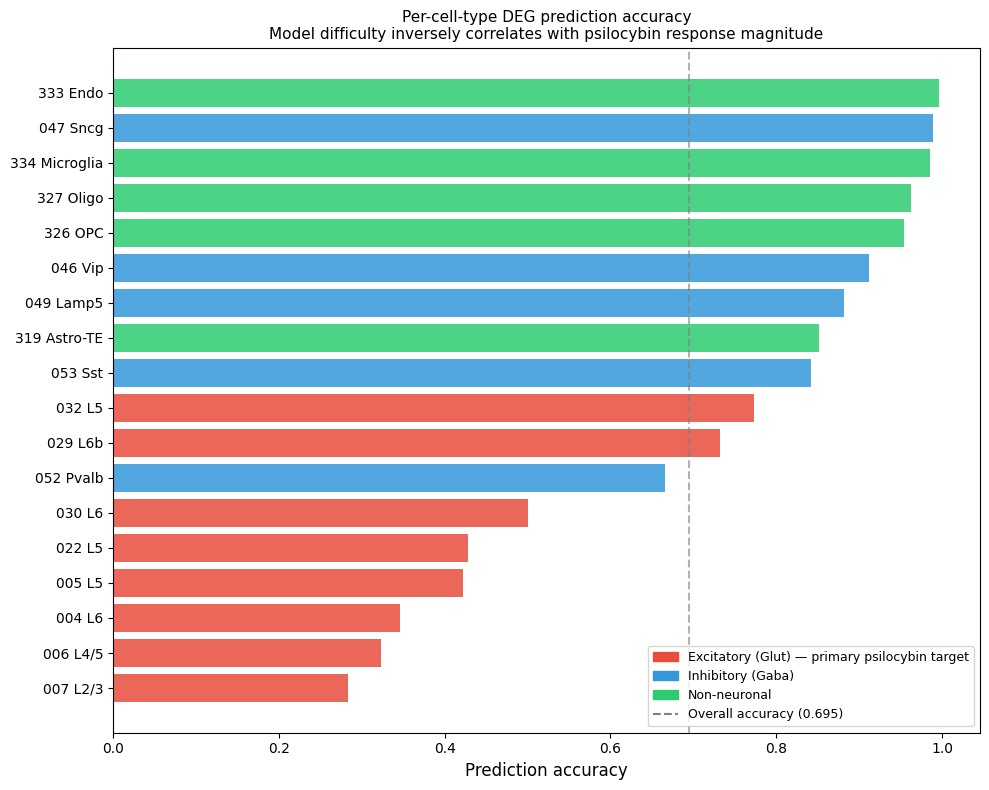

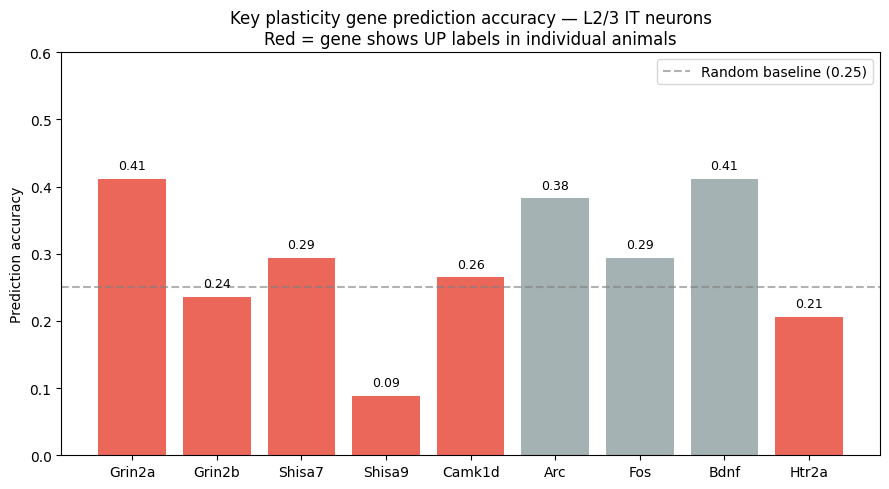

In [ ]:
# ── Figure 1: Cell-type accuracy bar chart ────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

sorted_rows = sorted(ct_rows, key=lambda x: x[1])
ct_labels_plot = [' '.join(ct.split()[:2]) for ct, _, _ in sorted_rows]
ct_accs_plot   = [acc for _, acc, _ in sorted_rows]
colors_plot    = ['#E74C3C' if 'Glut' in ct else
                  '#3498DB' if 'Gaba' in ct else
                  '#2ECC71' for ct, _, _ in sorted_rows]

ax.barh(ct_labels_plot, ct_accs_plot, color=colors_plot, alpha=0.85)
ax.axvline(x=0.695, color='gray', linestyle='--', alpha=0.6, linewidth=1.5)
ax.set_xlabel('Prediction accuracy', fontsize=12)
ax.set_title('Per-cell-type DEG prediction accuracy\n'
             'Model difficulty inversely correlates with psilocybin response magnitude',
             fontsize=11)
ax.legend(handles=[
    Patch(color='#E74C3C', label='Excitatory (Glut) — primary psilocybin target'),
    Patch(color='#3498DB', label='Inhibitory (Gaba)'),
    Patch(color='#2ECC71', label='Non-neuronal'),
    plt.Line2D([0],[0], color='gray', linestyle='--',
               label='Overall accuracy (0.695)')
], fontsize=9)
plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/figures/celltype_accuracy_v2.png', dpi=150)
plt.show()

# ── Figure 2: Plasticity gene accuracy ────────────────────────────────────
plasticity_data = []
for g in ['Grin2a', 'Grin2b', 'Shisa7', 'Shisa9', 'Camk1d',
          'Arc', 'Fos', 'Bdnf', 'Htr2a']:
    if g not in gene_total: continue
    acc = gene_correct[g] / gene_total[g]
    uniq, cnts = np.unique(gene_true_labels[g], return_counts=True)
    dominant = class_names[int(uniq[np.argmax(cnts)])]
    n_up = sum(c for u, c in zip(uniq, cnts) if int(u) == UP)
    plasticity_data.append((g, acc, dominant, n_up))

fig, ax = plt.subplots(figsize=(9, 5))
genes_p  = [d[0] for d in plasticity_data]
accs_p   = [d[1] for d in plasticity_data]
n_ups    = [d[3] for d in plasticity_data]
bar_colors = ['#E74C3C' if n > 0 else '#95A5A6' for n in n_ups]

bars = ax.bar(genes_p, accs_p, color=bar_colors, alpha=0.85)
ax.axhline(y=0.25, color='gray', linestyle='--', alpha=0.6,
           label='Random baseline (0.25)')
ax.set_ylabel('Prediction accuracy')
ax.set_title('Key plasticity gene prediction accuracy — L2/3 IT neurons\n'
             'Red = gene shows UP labels in individual animals')
ax.legend()
ax.set_ylim(0, 0.6)
for bar, (g, acc, dom, n_up) in zip(bars, plasticity_data):
    ax.text(bar.get_x() + bar.get_width()/2, acc + 0.01,
            f'{acc:.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/figures/plasticity_gene_accuracy.png', dpi=150)
plt.show()

L2/3 IT Psilo individual examples: 17

Genes with UP labels (n>=3 animals):      234
Genes with DOWN labels (n>=3 animals):    122
Genes with NEUTRAL labels (n>=3 animals): 510

Expression variance across animals:
  UP genes      — mean std: 0.2403, median: 0.2164
  DOWN genes    — mean std: 0.1690, median: 0.1443
  NEUTRAL genes — mean std: 0.2638, median: 0.2569

Mann-Whitney U test (UP vs DOWN variance):
  U=18615.0, p=0.0000
  UP and DOWN genes have significantly different variance


/tmp/ipykernel_1665/1572039175.py:87: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([down_vars, neutral_vars, up_vars],


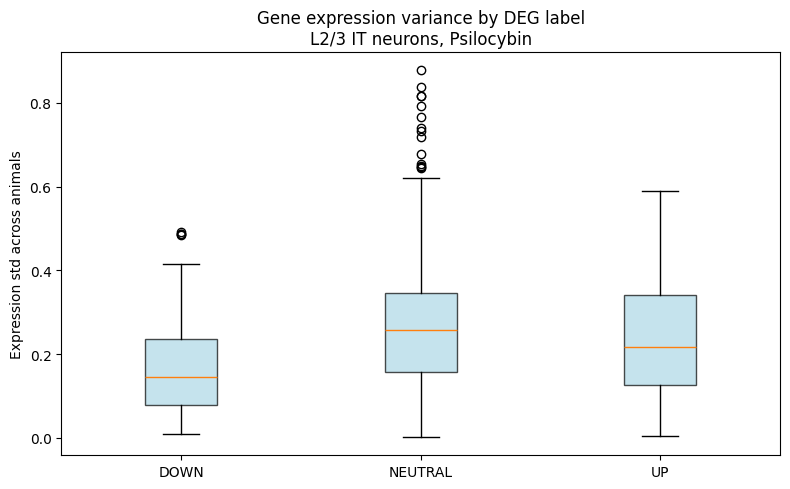

In [ ]:
# ── UP gene variance check ────────────────────────────────────────────────
# Question: are UP-labeled genes more variable across animals than DOWN-labeled genes?
# If yes, the data ceiling is the constraint, not the model

import numpy as np
from collections import defaultdict

# Focus on L2/3 IT psilocybin examples — the most biologically interesting
target_examples = [
    i for i, m in enumerate(metadata_v5)
    if m['cell_type'] == '007 L2/3 IT CTX Glut'
    and m['example_type'] == 'individual'
    and m['drug'] == 'Psilo'
]

print(f"L2/3 IT Psilo individual examples: {len(target_examples)}")

TIMEPOINT_LIST = ['0h', '1h', '2h', '4h', '24h', '72h']

# For each gene, collect its expression values across animals at its measured timepoint
gene_expressions_by_label = defaultdict(list)  # label -> list of (gene, expr_values)
gene_variance_up   = {}
gene_variance_down = {}
gene_variance_neutral = {}

for gi, gene in enumerate(final_genes_500):
    up_exprs      = []
    down_exprs    = []
    neutral_exprs = []

    for i in target_examples:
        meta   = metadata_v5[i]
        tp_idx = meta['timepoint_idx']
        if tp_idx < 0:
            continue

        expr_val  = input_tensor_v5[i, gi, tp_idx].item()
        true_label = label_tensor_v5[i, gi, tp_idx].item()

        if expr_val == NOT_MEASURED:
            continue

        if true_label == UP:
            up_exprs.append(expr_val)
        elif true_label == DOWN:
            down_exprs.append(expr_val)
        elif true_label == NEUTRAL:
            neutral_exprs.append(expr_val)

    if len(up_exprs) >= 3:
        gene_variance_up[gene] = np.std(up_exprs)
    if len(down_exprs) >= 3:
        gene_variance_down[gene] = np.std(down_exprs)
    if len(neutral_exprs) >= 3:
        gene_variance_neutral[gene] = np.std(neutral_exprs)

print(f"\nGenes with UP labels (n>=3 animals):      {len(gene_variance_up)}")
print(f"Genes with DOWN labels (n>=3 animals):    {len(gene_variance_down)}")
print(f"Genes with NEUTRAL labels (n>=3 animals): {len(gene_variance_neutral)}")

# Compare variance distributions
up_vars      = list(gene_variance_up.values())
down_vars    = list(gene_variance_down.values())
neutral_vars = list(gene_variance_neutral.values())

print(f"\nExpression variance across animals:")
print(f"  UP genes      — mean std: {np.mean(up_vars):.4f}, "
      f"median: {np.median(up_vars):.4f}")
print(f"  DOWN genes    — mean std: {np.mean(down_vars):.4f}, "
      f"median: {np.median(down_vars):.4f}")
print(f"  NEUTRAL genes — mean std: {np.mean(neutral_vars):.4f}, "
      f"median: {np.median(neutral_vars):.4f}")

# Statistical test
from scipy.stats import mannwhitneyu
if up_vars and down_vars:
    stat, p = mannwhitneyu(up_vars, down_vars, alternative='two-sided')
    print(f"\nMann-Whitney U test (UP vs DOWN variance):")
    print(f"  U={stat:.1f}, p={p:.4f}")
    if p < 0.05:
        print("  UP and DOWN genes have significantly different variance")
    else:
        print("  No significant difference in variance between UP and DOWN genes")

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([down_vars, neutral_vars, up_vars],
           labels=['DOWN', 'NEUTRAL', 'UP'],
           patch_artist=True,
           boxprops=dict(facecolor='lightblue', alpha=0.7))
ax.set_ylabel('Expression std across animals')
ax.set_title('Gene expression variance by DEG label\nL2/3 IT neurons, Psilocybin')
plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/figures/variance_by_label.png', dpi=150)
plt.show()

In [ ]:
# Check variance asymmetry across all excitatory cell types
excitatory_cts = [ct for ct in CELL_TYPES if 'Glut' in ct]

results = []
for ct in excitatory_cts:
    ct_examples = [
        i for i, m in enumerate(metadata_v5)
        if m['cell_type'] == ct
        and m['example_type'] == 'individual'
        and m['drug'] == 'Psilo'
    ]
    if len(ct_examples) < 5:
        continue

    up_vars_ct, down_vars_ct = [], []
    for gi in range(N_GENES):
        up_e, down_e = [], []
        for i in ct_examples:
            tp_i = metadata_v5[i]['timepoint_idx']
            if tp_i < 0: continue
            val = input_tensor_v5[i, gi, tp_i].item()
            lbl = label_tensor_v5[i, gi, tp_i].item()
            if val == NOT_MEASURED: continue
            if lbl == UP: up_e.append(val)
            elif lbl == DOWN: down_e.append(val)
        if len(up_e) >= 3: up_vars_ct.append(np.std(up_e))
        if len(down_e) >= 3: down_vars_ct.append(np.std(down_e))

    if up_vars_ct and down_vars_ct:
        stat, p = mannwhitneyu(up_vars_ct, down_vars_ct,
                               alternative='two-sided')
        results.append({
            'cell_type': ct.split(' ')[1],
            'up_mean_std': np.mean(up_vars_ct),
            'down_mean_std': np.mean(down_vars_ct),
            'ratio': np.mean(up_vars_ct) / np.mean(down_vars_ct),
            'p_value': p,
            'n_up_genes': len(up_vars_ct),
            'n_down_genes': len(down_vars_ct)
        })

print(f"{'Cell type':<12} {'UP std':>8} {'DOWN std':>9} "
      f"{'Ratio':>7} {'p-value':>10} {'n_up':>6} {'n_down':>7}")
print("-" * 65)
for r in sorted(results, key=lambda x: -x['ratio']):
    print(f"{r['cell_type']:<12} {r['up_mean_std']:>8.4f} "
          f"{r['down_mean_std']:>9.4f} {r['ratio']:>7.2f} "
          f"{r['p_value']:>10.4f} {r['n_up_genes']:>6} "
          f"{r['n_down_genes']:>7}")

Cell type      UP std  DOWN std   Ratio    p-value   n_up  n_down
-----------------------------------------------------------------
L4/5           0.2471    0.1531    1.61     0.0000    237     127
L5             0.2452    0.1652    1.48     0.0000    223     130
L6             0.2441    0.1705    1.43     0.0000    214     124
L2/3           0.2403    0.1690    1.42     0.0000    234     122
L5             0.2624    0.1914    1.37     0.0004     97      67
L6             0.2292    0.1842    1.24     0.0028    197     126
L6b            0.2993    0.2550    1.17     0.1999     75      53
L5             0.1966    0.1835    1.07     0.4007    201     106


In [ ]:
import types

def get_attention_weights(self, x, ct_ids, drug_ids):
    B = x.shape[0]
    tokens = self.input_proj(self.normalize(x).reshape(B, -1).unsqueeze(-1))
    g_ids = torch.arange(self.n_genes, device=x.device)
    g_ids = g_ids.unsqueeze(1).expand(-1, self.n_timepoints).reshape(-1)
    t_ids = torch.arange(self.n_timepoints, device=x.device)
    t_ids = t_ids.unsqueeze(0).expand(self.n_genes, -1).reshape(-1)
    tokens = (tokens
              + self.gene_embedding(g_ids)
              + self.time_encoding[t_ids]
              + (self.celltype_embedding(ct_ids) +
                 self.drug_embedding(drug_ids)).unsqueeze(1))
    tokens = self.dropout_layer(self.input_norm(tokens))

    all_attn_weights = []
    x_curr = tokens
    for layer in self.transformer.layers:
        attn_out, attn_weights = layer.self_attn(
            x_curr, x_curr, x_curr,
            need_weights=True,
            average_attn_weights=True
        )
        all_attn_weights.append(attn_weights.detach().cpu())
        x_curr = layer(x_curr)

    return all_attn_weights

# Bind to existing model instance
model.get_attention_weights = types.MethodType(get_attention_weights, model)
print("Attention weight extraction method added.")

# Test
model.eval()
with torch.no_grad():
    test_attn = model.get_attention_weights(
        input_clean[:1].to(device),
        torch.tensor([metadata_v5[0]['celltype_idx']]).to(device),
        torch.tensor([metadata_v5[0]['drug_idx']]).to(device)
    )
print(f"Attention weights: {len(test_attn)} layers, "
      f"shape per layer: {test_attn[0].shape}")

Attention weight extraction method added.
Attention weights: 4 layers, shape per layer: torch.Size([1, 3060, 3060])


L2/3 IT Psilo population examples: 1
Using example: {'animal': 'population', 'cell_type': '007 L2/3 IT CTX Glut', 'drug': 'Psilo', 'timepoint': 'all', 'timepoint_idx': -1, 'celltype_idx': 3, 'drug_idx': 0, 'example_type': 'population'}
Averaged attention matrix shape: torch.Size([3060, 3060])


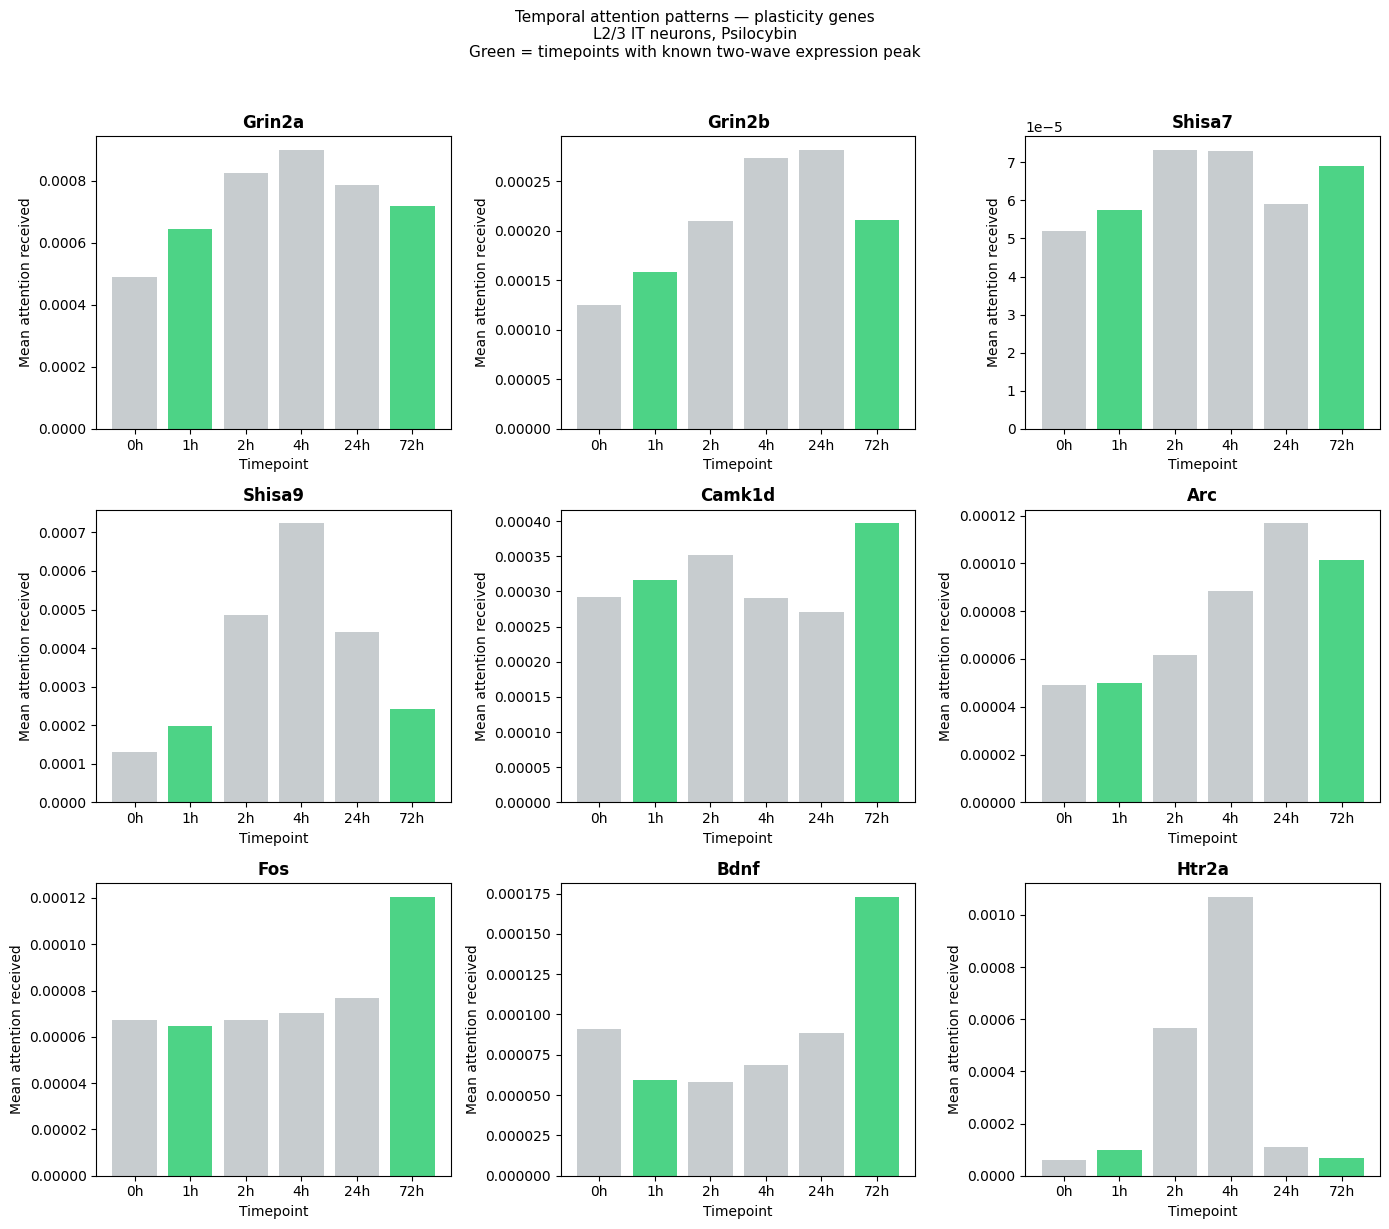


Two-hump attention score per gene:
Gene           1h attn   24h attn   72h attn   peak_ratio
-------------------------------------------------------
Grin2a        0.000646   0.000787   0.000719        0.867
Grin2b        0.000158   0.000282   0.000211        0.656
Shisa7        0.000057   0.000059   0.000069        1.071
Shisa9        0.000198   0.000440   0.000243        0.500
Camk1d        0.000316   0.000271   0.000397        1.315
Arc           0.000050   0.000117   0.000101        0.649
Fos           0.000065   0.000077   0.000120        1.204
Bdnf          0.000059   0.000088   0.000173        1.314
Htr2a         0.000099   0.000109   0.000067        0.759


In [ ]:
# ── Temporal attention analysis for plasticity genes ─────────────────────
# Each token position = gene_idx * n_timepoints + timepoint_idx
# So Grin2a at 1h = gene_idx_grin2a * 6 + 1

TIMEPOINT_LIST = ['0h', '1h', '2h', '4h', '24h', '72h']
TIMEPOINT_NAMES = ['0h', '1h', '2h', '4h', '24h', '72h']

# Map gene names to token positions
def gene_tp_to_pos(gene_name, tp_name, final_genes, n_timepoints):
    if gene_name not in final_genes:
        return None
    gene_idx = final_genes.index(gene_name)
    tp_idx   = TIMEPOINT_LIST.index(tp_name)
    return gene_idx * n_timepoints + tp_idx

# Use a psilocybin L2/3 IT population example — has all timepoints filled
pop_examples_l23 = [
    i for i, m in enumerate(metadata_v5)
    if m['cell_type'] == '007 L2/3 IT CTX Glut'
    and m['example_type'] == 'population'
    and m['drug'] == 'Psilo'
]
print(f"L2/3 IT Psilo population examples: {len(pop_examples_l23)}")

if len(pop_examples_l23) == 0:
    # Fall back to individual examples at 1h
    pop_examples_l23 = [
        i for i, m in enumerate(metadata_v5)
        if m['cell_type'] == '007 L2/3 IT CTX Glut'
        and m['example_type'] == 'individual'
        and m['drug'] == 'Psilo'
        and m['timepoint'] == '1h'
    ]
    print(f"Falling back to 1h individual examples: {len(pop_examples_l23)}")

ex_idx = pop_examples_l23[0]
meta   = metadata_v5[ex_idx]
print(f"Using example: {meta}")

model.eval()
with torch.no_grad():
    attn_weights = model.get_attention_weights(
        input_clean[ex_idx:ex_idx+1].to(device),
        torch.tensor([meta['celltype_idx']]).to(device),
        torch.tensor([meta['drug_idx']]).to(device)
    )

# Average attention across all 4 layers
avg_attn = torch.stack(attn_weights).mean(0)[0]  # (3060, 3060)
print(f"Averaged attention matrix shape: {avg_attn.shape}")

# ── For each plasticity gene, extract attention it receives from each timepoint
plasticity_genes = ['Grin2a', 'Grin2b', 'Shisa7', 'Shisa9',
                    'Camk1d', 'Arc', 'Fos', 'Bdnf', 'Htr2a']

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.flatten()

for plot_idx, gene in enumerate(plasticity_genes):
    if gene not in final_genes_500:
        axes[plot_idx].set_title(f'{gene} (not in set)')
        continue

    ax = axes[plot_idx]
    tp_attention = []

    for tp in TIMEPOINT_LIST:
        pos = gene_tp_to_pos(gene, tp, final_genes_500, N_TIMEPOINTS)
        if pos is None:
            tp_attention.append(0)
            continue
        # How much attention does this gene-timepoint token receive
        # from all other tokens? Sum incoming attention weights
        incoming_attn = avg_attn[:, pos].mean().item()
        tp_attention.append(incoming_attn)

    ax.bar(TIMEPOINT_NAMES, tp_attention,
           color=['#2ECC71' if tp in ['1h', '72h'] else
                  '#BDC3C7' for tp in TIMEPOINT_LIST],
           alpha=0.85)
    ax.set_title(gene, fontweight='bold')
    ax.set_ylabel('Mean attention received')
    ax.set_xlabel('Timepoint')

plt.suptitle('Temporal attention patterns — plasticity genes\n'
             'L2/3 IT neurons, Psilocybin\n'
             'Green = timepoints with known two-wave expression peak',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/figures/temporal_attention.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Quantify two-hump pattern ──────────────────────────────────────────────
print("\nTwo-hump attention score per gene:")
print(f"{'Gene':<12} {'1h attn':>9} {'24h attn':>10} {'72h attn':>10} "
      f"{'peak_ratio':>12}")
print("-" * 55)
for gene in plasticity_genes:
    if gene not in final_genes_500: continue
    attn_per_tp = []
    for tp in TIMEPOINT_LIST:
        pos = gene_tp_to_pos(gene, tp, final_genes_500, N_TIMEPOINTS)
        attn_per_tp.append(avg_attn[:, pos].mean().item() if pos else 0)

    attn_1h  = attn_per_tp[1]
    attn_24h = attn_per_tp[4]
    attn_72h = attn_per_tp[5]
    # Peak ratio: average of peaks vs valley
    if attn_24h > 0:
        ratio = ((attn_1h + attn_72h) / 2) / attn_24h
    else:
        ratio = 0
    print(f"{gene:<12} {attn_1h:>9.6f} {attn_24h:>10.6f} "
          f"{attn_72h:>10.6f} {ratio:>12.3f}")

In [ ]:
# Pick a few housekeeping genes for comparison
# These should have flat expression across timepoints
housekeeping = ['Actb', 'Gapdh', 'Rpl13a', 'Hprt', 'Pgk1']
housekeeping_in_set = [g for g in housekeeping if g in final_genes_500]
print(f"Housekeeping genes in set: {housekeeping_in_set}")

# Also get all genes and find ones with flat attention
all_gene_tp_attns = []
for gi, gene in enumerate(final_genes_500):
    tp_attns = []
    for tp in TIMEPOINT_LIST:
        pos = gi * N_TIMEPOINTS + TIMEPOINT_LIST.index(tp)
        tp_attns.append(avg_attn[:, pos].mean().item())

    # Coefficient of variation across timepoints — low = flat
    cv = np.std(tp_attns) / (np.mean(tp_attns) + 1e-10)
    all_gene_tp_attns.append((gene, tp_attns, cv))

# Most flat genes (lowest CV)
flattest = sorted(all_gene_tp_attns, key=lambda x: x[2])[:5]
print("\nFlattest attention profiles (housekeeping candidates):")
for gene, attns, cv in flattest:
    print(f"  {gene}: CV={cv:.4f}, attns={[f'{a:.6f}' for a in attns]}")

# Most temporally variable genes (highest CV)
most_variable = sorted(all_gene_tp_attns, key=lambda x: -x[2])[:10]
print("\nMost temporally variable attention profiles:")
for gene, attns, cv in most_variable:
    attn_72h = attns[5]
    attn_1h  = attns[1]
    attn_24h = attns[4]
    print(f"  {gene}: CV={cv:.4f}, "
          f"1h={attn_1h:.6f}, 24h={attn_24h:.6f}, 72h={attn_72h:.6f}")

Housekeeping genes in set: []

Flattest attention profiles (housekeeping candidates):
  Rapgefl1: CV=0.0503, attns=['0.000081', '0.000088', '0.000090', '0.000091', '0.000080', '0.000083']
  Nr4a3: CV=0.0571, attns=['0.000042', '0.000042', '0.000045', '0.000045', '0.000045', '0.000050']
  Celf3: CV=0.0740, attns=['0.000145', '0.000171', '0.000156', '0.000178', '0.000156', '0.000149']
  Cst3: CV=0.0770, attns=['0.000074', '0.000093', '0.000091', '0.000093', '0.000093', '0.000090']
  Ktn1: CV=0.0803, attns=['0.000114', '0.000128', '0.000143', '0.000132', '0.000125', '0.000144']

Most temporally variable attention profiles:
  Eml5: CV=1.9622, 1h=0.000256, 24h=0.000985, 72h=0.000138
  Celf4: CV=1.8925, 1h=0.000285, 24h=0.001315, 72h=0.000235
  Necab1: CV=1.8573, 1h=0.000121, 24h=0.000271, 72h=0.000121
  Htr1f: CV=1.6680, 1h=0.000241, 24h=0.000832, 72h=0.007802
  Spata7: CV=1.6271, 1h=0.000142, 24h=0.000283, 72h=0.000110
  Tiparp: CV=1.6037, 1h=0.000057, 24h=0.000210, 72h=0.000072
  Madd: CV

In [ ]:
# Check Htr1f in the DEG database — what does it actually do across timepoints?
import sqlite3
conn = sqlite3.connect(f'{DRIVE_PATH}/data/differential_expression_v2.sqlite')

htr1f_degs = pd.read_sql("""
    SELECT celltype, comparison_id, log2FoldChange, padj
    FROM de_results
    WHERE gene_name = 'Htr1f'
    AND padj < 0.05
    ORDER BY celltype, comparison_id
""", conn)

print("Htr1f significant DEGs across conditions:")
print(htr1f_degs.to_string())

# Also check what other serotonin receptors are in our gene set
serotonin_genes = [g for g in final_genes_500 if 'Htr' in g]
print(f"\nSerotonin receptor genes in set: {serotonin_genes}")

# Their attention variability
print("\nTemporal attention CV for serotonin receptors:")
for gene, attns, cv in sorted(all_gene_tp_attns, key=lambda x: x[2],
                               reverse=True):
    if gene in serotonin_genes:
        print(f"  {gene}: CV={cv:.4f}, "
              f"1h={attns[1]:.6f}, 24h={attns[4]:.6f}, "
              f"72h={attns[5]:.6f}")

conn.close()

Htr1f significant DEGs across conditions:
             celltype        comparison_id  log2FoldChange      padj
0  022 L5 ET CTX Glut  1h_Psilo_vs_0h_none       -0.532059  0.001207
1    029 L6b CTX Glut  1h_Psilo_vs_0h_none       -0.489836  0.029094
2  030 L6 CT CTX Glut  1h_Psilo_vs_0h_none       -0.699786  0.000043
3  032 L5 NP CTX Glut  1h_Psilo_vs_0h_none       -0.663276  0.000068
4      049 Lamp5 Gaba  1h_Psilo_vs_0h_none       -0.664984  0.012729
5      052 Pvalb Gaba  1h_Psilo_vs_0h_none       -0.759840  0.000214
6        053 Sst Gaba  1h_Psilo_vs_0h_none       -0.652021  0.004459

Serotonin receptor genes in set: ['Htra1', 'Htr1f', 'Htr2a', 'Htr1a', 'Htr2c']

Temporal attention CV for serotonin receptors:
  Htr1f: CV=1.6680, 1h=0.000241, 24h=0.000832, 72h=0.007802
  Htr2a: CV=1.1412, 1h=0.000099, 24h=0.000109, 72h=0.000067
  Htr1a: CV=0.6205, 1h=0.000096, 24h=0.000124, 72h=0.000350
  Htra1: CV=0.2071, 1h=0.000049, 24h=0.000071, 72h=0.000085
  Htr2c: CV=0.1192, 1h=0.000068, 24h=0

In [ ]:
conn = sqlite3.connect(f'{DRIVE_PATH}/data/differential_expression_v2.sqlite')

# Get Htr1f mean expression across all timepoints
htr1f_expr = pd.read_sql("""
    SELECT celltype, time, drug, mean_expression
    FROM gene_expression
    WHERE gene_name = 'Htr1f'
    AND celltype IN ('007 L2/3 IT CTX Glut', '022 L5 ET CTX Glut',
                     '030 L6 CT CTX Glut')
    ORDER BY celltype, drug, time
""", conn)
print("Htr1f mean expression across timepoints:")
print(htr1f_expr.to_string())

# Also check which genes Htr1f attends TO most at 72h
# i.e. from Htr1f's 72h position, what does it look at?
htr1f_idx = final_genes_500.index('Htr1f')
htr1f_72h_pos = htr1f_idx * N_TIMEPOINTS + 5  # 72h is index 5

# Outgoing attention from Htr1f at 72h
outgoing = avg_attn[htr1f_72h_pos, :]  # what Htr1f 72h attends to

# Top 20 positions it attends to
top_positions = outgoing.argsort(descending=True)[:20]
print("\nTop genes Htr1f@72h attends to:")
for pos in top_positions:
    g_idx = pos.item() // N_TIMEPOINTS
    t_idx = pos.item() % N_TIMEPOINTS
    gene_name = final_genes_500[g_idx]
    tp_name   = TIMEPOINT_LIST[t_idx]
    print(f"  {gene_name} @ {tp_name}: {outgoing[pos].item():.6f}")

conn.close()

Htr1f mean expression across timepoints:
                celltype time   drug  mean_expression
0   007 L2/3 IT CTX Glut   1h    Ket         0.720707
1   007 L2/3 IT CTX Glut  24h    Ket         0.751348
2   007 L2/3 IT CTX Glut   2h    Ket         0.695542
3   007 L2/3 IT CTX Glut   4h    Ket         0.737266
4   007 L2/3 IT CTX Glut  72h    Ket         0.707517
5   007 L2/3 IT CTX Glut   1h  Psilo         0.407651
6   007 L2/3 IT CTX Glut  24h  Psilo         0.447683
7   007 L2/3 IT CTX Glut   2h  Psilo         0.720155
8   007 L2/3 IT CTX Glut   4h  Psilo         0.833776
9   007 L2/3 IT CTX Glut  72h  Psilo         0.374583
10  007 L2/3 IT CTX Glut   0h   none         0.937901
11    022 L5 ET CTX Glut   1h    Ket         5.971743
12    022 L5 ET CTX Glut  24h    Ket         5.713127
13    022 L5 ET CTX Glut   2h    Ket         5.689956
14    022 L5 ET CTX Glut   4h    Ket         5.991293
15    022 L5 ET CTX Glut  72h    Ket         5.705128
16    022 L5 ET CTX Glut   1h  Psilo     

In [ ]:
# Confirm Htr1f 72h suppression is psilocybin-specific across all excitatory types
conn = sqlite3.connect(f'{DRIVE_PATH}/data/differential_expression_v2.sqlite')

htr1f_72h = pd.read_sql("""
    SELECT gene_name, celltype, comparison_id,
           log2FoldChange, padj
    FROM de_results
    WHERE gene_name = 'Htr1f'
    AND (comparison_id LIKE '72h_%')
    ORDER BY celltype
""", conn)

print("Htr1f at 72h — all comparisons:")
print(htr1f_72h.to_string())

# Also check expression directly
htr1f_72h_expr = pd.read_sql("""
    SELECT celltype, drug, mean_expression
    FROM gene_expression
    WHERE gene_name = 'Htr1f'
    AND time = '72h'
    ORDER BY celltype, drug
""", conn)

print("\nHtr1f mean expression at 72h by cell type and drug:")
# Pivot to compare psilo vs ket side by side
pivot = htr1f_72h_expr.pivot(
    index='celltype', columns='drug', values='mean_expression')
pivot['psilo_vs_ket'] = pivot['Psilo'] - pivot['Ket']
print(pivot.round(3).to_string())

conn.close()

Htr1f at 72h — all comparisons:
   gene_name              celltype         comparison_id  log2FoldChange      padj
0      Htr1f    004 L6 IT CTX Glut    72h_Ket_vs_0h_none        0.004924  0.995697
1      Htr1f    004 L6 IT CTX Glut  72h_Psilo_vs_0h_none       -0.100752  0.750018
2      Htr1f    005 L5 IT CTX Glut    72h_Ket_vs_0h_none        0.014716  0.995441
3      Htr1f    005 L5 IT CTX Glut  72h_Psilo_vs_0h_none       -0.078820  0.836169
4      Htr1f  006 L4/5 IT CTX Glut    72h_Ket_vs_0h_none        0.024684  0.992441
5      Htr1f  006 L4/5 IT CTX Glut  72h_Psilo_vs_0h_none       -0.047891  0.952285
6      Htr1f  007 L2/3 IT CTX Glut    72h_Ket_vs_0h_none        0.001403  0.992466
7      Htr1f  007 L2/3 IT CTX Glut  72h_Psilo_vs_0h_none       -0.119687  0.219223
8      Htr1f    022 L5 ET CTX Glut    72h_Ket_vs_0h_none       -0.096209  0.896886
9      Htr1f    022 L5 ET CTX Glut  72h_Psilo_vs_0h_none       -0.152121  0.410323
10     Htr1f      029 L6b CTX Glut    72h_Ket_vs_0h_non

In [ ]:
# Full Htr1f expression timeline — psilo vs ket comparison
conn = sqlite3.connect(f'{DRIVE_PATH}/data/differential_expression_v2.sqlite')

htr1f_full = pd.read_sql("""
    SELECT time, drug,
           AVG(mean_expression) as avg_expr,
           COUNT(*) as n_celltypes
    FROM gene_expression
    WHERE gene_name = 'Htr1f'
    GROUP BY time, drug
    ORDER BY drug, time
""", conn)

print("Htr1f average expression across all cell types:")
pivot_full = htr1f_full.pivot(
    index='time', columns='drug', values='avg_expr')
pivot_full = pivot_full.reindex(['0h', '1h', '2h', '4h', '24h', '72h'])
pivot_full['psilo_vs_ket'] = pivot_full['Psilo'] - pivot_full['Ket']
pivot_full['psilo_vs_baseline'] = pivot_full['Psilo'] - pivot_full['none']
print(pivot_full.round(3).to_string())

conn.close()

Htr1f average expression across all cell types:
drug    Ket  Psilo   none  psilo_vs_ket  psilo_vs_baseline
time                                                      
0h      NaN    NaN  2.692           NaN                NaN
1h    2.573  2.025    NaN        -0.548                NaN
2h    2.494  2.618    NaN         0.124                NaN
4h    2.593  2.542    NaN        -0.051                NaN
24h   2.517  2.446    NaN        -0.070                NaN
72h   2.639  2.362    NaN        -0.277                NaN


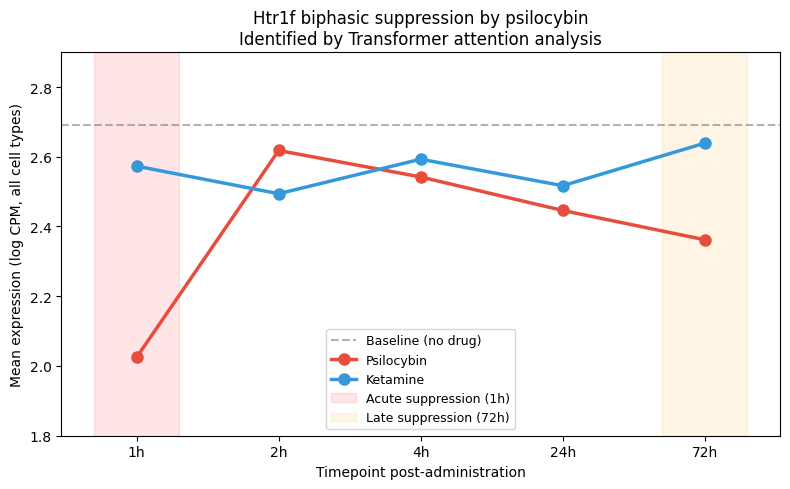

Biphasic pattern summary:
  Baseline:           2.692
  1h  Psilo vs Ket:   -0.548 (Psilo=2.025)
  2h  Psilo vs Ket:   +0.124 (recovery)
  72h Psilo vs Ket:   -0.277 (Psilo=2.362)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 5))

timepoints = ['1h', '2h', '4h', '24h', '72h']
psilo_vals = [2.025, 2.618, 2.542, 2.446, 2.362]
ket_vals   = [2.573, 2.494, 2.593, 2.517, 2.639]
baseline   = 2.692

ax.axhline(y=baseline, color='gray', linestyle='--',
           alpha=0.6, label='Baseline (no drug)')
ax.plot(timepoints, psilo_vals, 'o-', color='#E74C3C',
        linewidth=2.5, markersize=8, label='Psilocybin')
ax.plot(timepoints, ket_vals, 'o-', color='#3498DB',
        linewidth=2.5, markersize=8, label='Ketamine')

# Shade the two suppression phases
ax.axvspan(-0.3, 0.3, alpha=0.1, color='red', label='Acute suppression (1h)')
ax.axvspan(3.7, 4.3, alpha=0.1, color='orange', label='Late suppression (72h)')

ax.set_xlabel('Timepoint post-administration')
ax.set_ylabel('Mean expression (log CPM, all cell types)')
ax.set_title('Htr1f biphasic suppression by psilocybin\n'
             'Identified by Transformer attention analysis')
ax.legend(fontsize=9)
ax.set_ylim(1.8, 2.9)

plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/figures/htr1f_biphasic.png', dpi=150)
plt.show()

print("Biphasic pattern summary:")
print(f"  Baseline:           {baseline:.3f}")
print(f"  1h  Psilo vs Ket:   {psilo_vals[0]-ket_vals[0]:+.3f} "
      f"(Psilo={psilo_vals[0]:.3f})")
print(f"  2h  Psilo vs Ket:   {psilo_vals[1]-ket_vals[1]:+.3f} "
      f"(recovery)")
print(f"  72h Psilo vs Ket:   {psilo_vals[4]-ket_vals[4]:+.3f} "
      f"(Psilo={psilo_vals[4]:.3f})")

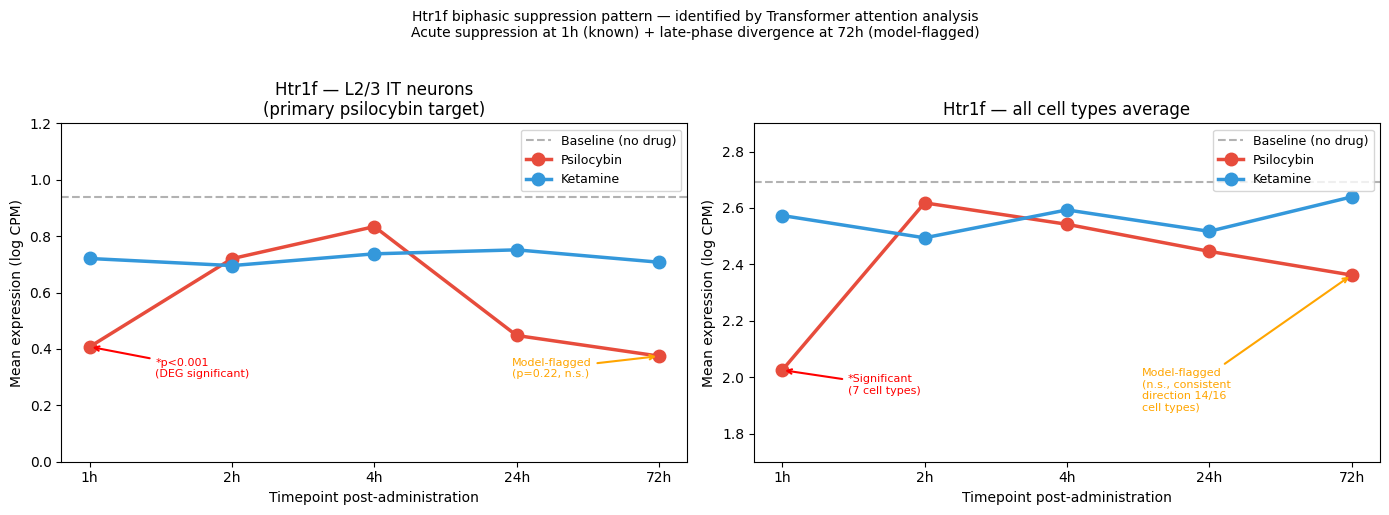

L2/3 IT Htr1f values:
drug    Ket  Psilo  none
time                    
1h    0.721  0.408   NaN
2h    0.696  0.720   NaN
4h    0.737  0.834   NaN
24h   0.751  0.448   NaN
72h   0.708  0.375   NaN


In [ ]:
# ── Clean Htr1f figure — L2/3 IT specific + all cell types ───────────────
conn = sqlite3.connect(f'{DRIVE_PATH}/data/differential_expression_v2.sqlite')

htr1f_l23 = pd.read_sql("""
    SELECT time, drug, mean_expression
    FROM gene_expression
    WHERE gene_name = 'Htr1f'
    AND celltype = '007 L2/3 IT CTX Glut'
    ORDER BY drug, time
""", conn)
conn.close()

# Pivot L2/3 IT data
pivot_l23 = htr1f_l23.pivot(
    index='time', columns='drug', values='mean_expression')
pivot_l23 = pivot_l23.reindex(['1h', '2h', '4h', '24h', '72h'])

# All cell type averages from before
psilo_all = [2.025, 2.618, 2.542, 2.446, 2.362]
ket_all   = [2.573, 2.494, 2.593, 2.517, 2.639]

timepoints = ['1h', '2h', '4h', '24h', '72h']
baseline_l23 = 0.938  # L2/3 IT 0h none from earlier
baseline_all = 2.692

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel 1: L2/3 IT ──
ax = axes[0]
ax.axhline(y=baseline_l23, color='gray', linestyle='--',
           alpha=0.6, label='Baseline (no drug)')
ax.plot(timepoints, pivot_l23['Psilo'].values, 'o-',
        color='#E74C3C', linewidth=2.5, markersize=9, label='Psilocybin')
ax.plot(timepoints, pivot_l23['Ket'].values, 'o-',
        color='#3498DB', linewidth=2.5, markersize=9, label='Ketamine')

# Mark significant timepoint
ax.annotate('*p<0.001\n(DEG significant)', xy=('1h', pivot_l23['Psilo']['1h']),
            xytext=(0.15, 0.25), textcoords='axes fraction',
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
            fontsize=8, color='red')

# Mark 72h as model-identified
ax.annotate('Model-flagged\n(p=0.22, n.s.)', xy=('72h', pivot_l23['Psilo']['72h']),
            xytext=(0.72, 0.25), textcoords='axes fraction',
            arrowprops=dict(arrowstyle='->', color='orange', lw=1.5),
            fontsize=8, color='orange')

ax.set_xlabel('Timepoint post-administration')
ax.set_ylabel('Mean expression (log CPM)')
ax.set_title('Htr1f — L2/3 IT neurons\n(primary psilocybin target)')
ax.legend(fontsize=9)
ax.set_ylim(0, 1.2)

# ── Panel 2: All cell types ──
ax = axes[1]
ax.axhline(y=baseline_all, color='gray', linestyle='--',
           alpha=0.6, label='Baseline (no drug)')
ax.plot(timepoints, psilo_all, 'o-', color='#E74C3C',
        linewidth=2.5, markersize=9, label='Psilocybin')
ax.plot(timepoints, ket_all, 'o-', color='#3498DB',
        linewidth=2.5, markersize=9, label='Ketamine')

ax.annotate('*Significant\n(7 cell types)', xy=('1h', psilo_all[0]),
            xytext=(0.15, 0.2), textcoords='axes fraction',
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
            fontsize=8, color='red')

ax.annotate('Model-flagged\n(n.s., consistent\ndirection 14/16\ncell types)',
            xy=('72h', psilo_all[4]),
            xytext=(0.62, 0.15), textcoords='axes fraction',
            arrowprops=dict(arrowstyle='->', color='orange', lw=1.5),
            fontsize=8, color='orange')

ax.set_xlabel('Timepoint post-administration')
ax.set_ylabel('Mean expression (log CPM)')
ax.set_title('Htr1f — all cell types average')
ax.legend(fontsize=9)
ax.set_ylim(1.7, 2.9)

plt.suptitle('Htr1f biphasic suppression pattern — identified by Transformer attention analysis\n'
             'Acute suppression at 1h (known) + late-phase divergence at 72h (model-flagged)',
             fontsize=10, y=1.02)
plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/figures/htr1f_biphasic_clean.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("L2/3 IT Htr1f values:")
print(pivot_l23.round(3))